# PCA vs Autoencoders — Dimensionality Reduction and Model Comparison

This notebook reproduces the experiments in the accompanying technical report.

## Goal
The goal of this project is to apply in practice and analyze the following approaches:
- **K-Means** for **clustering**
- **Neural Networks** (including **CNNs**) for **regression** and **multi-class classification**
- **Principal Component Analysis (PCA)** and **Autoencoders** for **dimensionality reduction**

We compare model performance when trained on:
- the **original** data (when manageable),
- the **PCA-reduced** data,
- the **AE-reduced** data.

## Datasets (UCI)
- **AirQuality (UCI id=360)** — *Regression* (tabular)
- **Paddy Dataset (UCI id=1186)** — *Clustering* (tabular)
- **RealWaste (UCI id=908)** — *Multi-class classification* (images)

All datasets are **downloaded automatically** at runtime (no Google Drive is required).

## Pipeline (high level)
1. Download datasets and create clean local folders under `/content/data`.
2. Preprocess each dataset:
   - handle missing/noisy data (when applicable)
   - standardize/normalize features
   - split into **train / validation / test**
3. Reduce dimensionality to a fixed latent dimension `d` using **PCA** and **AE** (same `d` for both on the same dataset).
4. Train and evaluate:
   - **K-Means** (clustering) → silhouette on val/test
   - **FNN** (regression) → MAE / RMSE / R²
   - **CNN** (classification) → accuracy / F1, confusion matrix, ROC/AUC
5. Produce summary tables and plots (learning curves + training times).

## Notes
- Random seed is fixed for reproducibility.
- Training can take longer on CPU; when GPU is available it is used automatically.


In [1]:
# =========================
# DATA DOWNLOAD (UCI) + UNZIP
# =========================
# This notebook is self-contained: datasets are downloaded at runtime
# All files are stored under /content/data to keep the workspace clean and reproducible

import os, glob, shutil, subprocess

# Root directory where we will store all datasets (downloaded + extracted)
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

def run(cmd):
    """Run a shell command; raises an error if the command fails"""
    subprocess.check_call(cmd, shell=True)

def fresh_dir(path):
    """Create an empty directory: if it exists, delete it first (clean re-run)"""
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

def download_and_unzip(url, zip_path, out_dir):
    """
    Download a .zip from 'url' into 'zip_path' and unzip it into 'out_dir'
    We remove previous files to guarantee reproducibility when re-running the notebook
    """
    if os.path.exists(zip_path):
        os.remove(zip_path)
    fresh_dir(out_dir)

    print(f"[1/2] Downloading: {url}")
    run(f"wget --show-progress -O '{zip_path}' '{url}'")

    size = os.path.getsize(zip_path)
    if size < 1024*1024:
        print(f"Downloaded: {size/1024:.1f} KB")
    else:
        print(f"Downloaded: {size/1024/1024:.1f} MB")

    print("[2/2] Unzipping (this can take a while)...")
    run(f"unzip -o '{zip_path}' -d '{out_dir}'")
    print("Unzip done.")

def find_one(pattern, root):
    """
    Find a single file matching 'pattern' under 'root' recursively
    Used to locate the main CSV inside the extracted folders
    """
    hits = glob.glob(os.path.join(root, "**", pattern), recursive=True)
    if not hits:
        raise FileNotFoundError(f"Not found: {pattern} under {root}")
    return hits[0]

# -------------------------
# AirQuality (UCI id=360) — regression dataset (tabular)
# -------------------------
air_zip = os.path.join(DATA_DIR, "air_quality.zip")
air_dir = os.path.join(DATA_DIR, "air_quality")
download_and_unzip("https://archive.ics.uci.edu/static/public/360/air%2Bquality.zip", air_zip, air_dir)
# Locate main CSV (path can vary depending on zip structure)
air_csv = find_one("AirQualityUCI.csv", air_dir)
print("AirQuality ready:", air_csv)

# -------------------------
# Paddy (UCI id=1186) — clustering dataset (tabular)
# -------------------------
paddy_zip = os.path.join(DATA_DIR, "paddy.zip")
paddy_dir = os.path.join(DATA_DIR, "paddy")
download_and_unzip("https://archive.ics.uci.edu/static/public/1186/paddy%2Bdataset.zip", paddy_zip, paddy_dir)
# Locate main CSV
paddy_csv = find_one("paddydataset.csv", paddy_dir)
print("Paddy ready:", paddy_csv)

# -------------------------
# RealWaste (UCI id=908) — multi-class image classification dataset
# -------------------------
rw_zip = os.path.join(DATA_DIR, "realwaste.zip")
rw_dir = os.path.join(DATA_DIR, "realwaste")
download_and_unzip("https://archive.ics.uci.edu/static/public/908/realwaste.zip", rw_zip, rw_dir)

# For torchvision ImageFolder, the "root" must be the folder that contains the class subfolders
# The zip may contain nested folders (e.g., realwaste-main/RealWaste), so we search for a directory that contains at least some known class names
candidates = []
for p in glob.glob(os.path.join(rw_dir, "**"), recursive=True):
    if os.path.isdir(p):
        sub = os.listdir(p)
        # Heuristic: a directory containing multiple expected class folders
        if "Cardboard" in sub and "Plastic" in sub:
            candidates.append(p)
realwaste_root = candidates[0] if candidates else rw_dir
print("RealWaste root for ImageFolder:", realwaste_root)


[1/2] Downloading: https://archive.ics.uci.edu/static/public/360/air%2Bquality.zip
Downloaded: 1.5 MB
[2/2] Unzipping (this can take a while)...
Unzip done.
AirQuality ready: /content/data/air_quality/AirQualityUCI.csv
[1/2] Downloading: https://archive.ics.uci.edu/static/public/1186/paddy%2Bdataset.zip
Downloaded: 16.2 KB
[2/2] Unzipping (this can take a while)...
Unzip done.
Paddy ready: /content/data/paddy/paddydataset.csv
[1/2] Downloading: https://archive.ics.uci.edu/static/public/908/realwaste.zip
Downloaded: 656.6 MB
[2/2] Unzipping (this can take a while)...
Unzip done.
RealWaste root for ImageFolder: /content/data/realwaste/realwaste-main/RealWaste


In [3]:
# =========================
# IMPORTS + GLOBAL SETTINGS
# =========================
# This notebook uses:
# - NumPy/Pandas for tabular data handling
# - scikit-learn for preprocessing, PCA, K-Means, and metrics
# - PyTorch/Torchvision for neural networks (FNN, CNN) and image pipelines

import os, random, time
from collections import Counter  # convenient for class-distribution counts

import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt  # plots for learning curves and ROC curves

# -------------------------
# scikit-learn (tabular ML)
# -------------------------
from sklearn.model_selection import train_test_split  # split indices/arrays for train/val/test
from sklearn.compose import ColumnTransformer         # apply different preprocessing to numeric/categorical columns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize  # encoding/scaling + ROC multiclass
from sklearn.decomposition import PCA                 # dimensionality reduction baseline
from sklearn.cluster import KMeans                    # clustering model (Paddy)
from sklearn.metrics import (                         # evaluation metrics
    silhouette_score,                                 # clustering metric
    mean_absolute_error, mean_squared_error, r2_score, # regression metrics
    accuracy_score, f1_score, confusion_matrix, classification_report,  # classification metrics
    roc_auc_score, roc_curve, auc                      # ROC/AUC metrics and curves
)
from sklearn.pipeline import Pipeline  # Lets you chain multiple preprocessing steps into a single fit/transform workflow
from sklearn.impute import SimpleImputer  # Handles missing values by imputing them (e.g., median for numeric, most frequent for categorical)
from sklearn.compose import ColumnTransformer  # Applies different transformations to different column subsets (numeric vs categorical) safely (no leakage)
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Standardizes numeric features (mean=0, std=1) and one-hot encodes categorical features
from sklearn.model_selection import KFold  # Splits the training set into K folds to perform K-fold cross-validation (more reliable hyperparameter selection)
from sklearn.metrics import silhouette_score  # Computes the silhouette coefficient to evaluate cluster quality (compactness + separation) for a given clustering
from sklearn.cluster import KMeans  # Implements the K-Means clustering algorithm (used to assign points to k clusters)
from sklearn.model_selection import TimeSeriesSplit # Time-series cross-validation: preserves chronological order and prevents leakage from future data into the past
from sklearn.model_selection import StratifiedKFold  # stratified CV for classification (keeps class proportions in each fold)

# -------------------------
# PyTorch + Torchvision
# -------------------------
import torch
import torch.nn as nn                                 # neural network layers/losses
from torch.utils.data import DataLoader, Subset, TensorDataset  # loaders + dataset wrappers
from torchvision.datasets import ImageFolder          # image dataset: folder-per-class
from torchvision import transforms                    # image preprocessing/augmentation

# -------------------------
# Reproducibility
# -------------------------
# Fix random seeds to make splits and training more reproducible across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------
# Device selection
# -------------------------
# Automatically use GPU if available, otherwise fall back to CPU
# All models/tensors should use `.to(device)` to follow this choice
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [4]:
# =========================
# UTILS
# =========================
# ---------- Helpers ----------
def cm_as_df(cm, class_names):
    """Convert a confusion matrix (ndarray) into a labeled pandas DataFrame"""
    return pd.DataFrame(cm, index=class_names, columns=class_names)

def eval_regression(y_true, y_pred):
    """
    Standard regression metrics used in the report/notebook
    Returns a dict so it can be easily converted to a DataFrame
    """
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}


# =========================
# TABULAR AUTOENCODER
# =========================
class TabularAE(nn.Module):
    """
    Simple fully-connected autoencoder for tabular data:
    X -> encoder -> z (bottleneck) -> decoder -> X_recon
    """
    def __init__(self, in_dim, bottleneck_dim, hidden=128):
        super().__init__()
        # Encoder maps input features to a low-dimensional latent code
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, bottleneck_dim)
        )
        # Decoder reconstructs the original input from the latent code
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, in_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


def train_tabular_ae(
    Xtr_np, Xva_np,
    bottleneck_dim,
    lr=1e-3, batch_size=256,
    max_epochs=100, patience=10,
    hidden=128,
    print_every=20
):
    """
    Train a tabular autoencoder with early stopping on validation MSE
    - Trains to reconstruct X (unsupervised)
    - Early stopping monitors val reconstruction MSE
    - Returns the best model (lowest val MSE)
    """
    # Convert numpy -> torch tensors
    Xtr = torch.tensor(Xtr_np, dtype=torch.float32)
    Xva = torch.tensor(Xva_np, dtype=torch.float32)

    # For AE training, targets are the inputs themselves
    tr_loader = DataLoader(TensorDataset(Xtr, Xtr), batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(TensorDataset(Xva, Xva), batch_size=batch_size, shuffle=False)

    model = TabularAE(
        in_dim=Xtr_np.shape[1],
        bottleneck_dim=bottleneck_dim,
        hidden=hidden
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    bad = 0  # epochs without improvement

    for epoch in range(1, max_epochs + 1):
        # ---- train ----
        model.train()
        tr_sum = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            tr_sum += loss.item() * xb.size(0)
        tr_mse = tr_sum / len(tr_loader.dataset)

        # ---- validation ----
        model.eval()
        va_sum = 0.0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                va_sum += loss_fn(model(xb), yb).item() * xb.size(0)
        va_mse = va_sum / len(va_loader.dataset)

        if epoch == 1 or epoch % print_every == 0:
            print(f"AE epoch {epoch:03d} | train MSE {tr_mse:.6f} | val MSE {va_mse:.6f}")

        # ---- early stopping ----
        if va_mse < best_val:
            best_val = va_mse
            # Save weights on CPU to be safe even if GPU disconnects
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stop @ epoch {epoch} (best val MSE {best_val:.6f})")
                break

    model.load_state_dict(best_state)
    return model


@torch.no_grad()
def encode_tabular_ae(model, X_np):
    """
    Encode data through the AE encoder only (returns latent codes as numpy)
    """
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32).to(device)
    return model.encoder(X).cpu().numpy()


# =========================
# FNN REGRESSOR (AirQuality)
# =========================
class FNNRegressor(nn.Module):
    """Small feed-forward neural network for regression"""
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_fnn_regressor(
    Xtr_np, ytr_np,
    Xva_np, yva_np,
    lr=1e-3, batch_size=256,
    max_epochs=300, patience=20,
    print_every=50
):
    """
    Train FNN regressor with early stopping on validation MSE
    Returns:
      - model (best on val)
      - train/val MSE histories (numpy arrays)
      - elapsed training time in seconds
    """
    # numpy -> torch
    Xtr = torch.tensor(Xtr_np, dtype=torch.float32)
    ytr = torch.tensor(ytr_np.reshape(-1, 1), dtype=torch.float32)
    Xva = torch.tensor(Xva_np, dtype=torch.float32)
    yva = torch.tensor(yva_np.reshape(-1, 1), dtype=torch.float32)

    tr_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(TensorDataset(Xva, yva), batch_size=batch_size, shuffle=False)

    model = FNNRegressor(in_dim=Xtr_np.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    bad = 0
    hist_tr, hist_va = [], []

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        # ---- train ----
        model.train()
        tr_sum = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            tr_sum += loss.item() * xb.size(0)
        tr_mse = tr_sum / len(tr_loader.dataset)

        # ---- validation ----
        model.eval()
        va_sum = 0.0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                va_sum += loss_fn(model(xb), yb).item() * xb.size(0)
        va_mse = va_sum / len(va_loader.dataset)

        hist_tr.append(tr_mse)
        hist_va.append(va_mse)

        if epoch == 1 or epoch % print_every == 0:
            print(f"Reg epoch {epoch:03d} | train MSE {tr_mse:.6f} | val MSE {va_mse:.6f}")

        # ---- early stopping ----
        if va_mse < best_val:
            best_val = va_mse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stop @ epoch {epoch} (best val MSE {best_val:.6f})")
                break

    model.load_state_dict(best_state)
    elapsed = time.time() - t0
    return model, np.array(hist_tr), np.array(hist_va), elapsed


@torch.no_grad()
def predict_regressor(model, X_np):
    """Predict regression outputs (numpy) from a trained regressor"""
    model.eval()
    X = torch.tensor(X_np, dtype=torch.float32).to(device)
    return model(X).cpu().numpy().reshape(-1)


def plot_curve(train_hist, val_hist, title, ylab="loss"):
    """Simple learning curve plot (train vs val)"""
    plt.figure(figsize=(7, 4))
    plt.plot(train_hist, label="train")
    plt.plot(val_hist, label="val")
    plt.xlabel("epoch")
    plt.ylabel(ylab)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# =========================
# CNN (RealWaste) — model + training + evaluation
# =========================
class SmallCNN(nn.Module):
    """Small CNN for 64x64 RGB images (used for RealWaste)"""
    def __init__(self, n_classes: int):
        super().__init__()
        # Feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8x8
        )
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def train_cnn(
    train_loader,
    val_loader,
    n_classes: int,
    max_epochs: int = 30,
    lr: float = 1e-3,
    patience: int = 5,
    min_delta: float = 1e-4,
    verbose: bool = True,
):
    """
    Train a CNN with early stopping based on validation cross-entropy loss
    Returns: model restored to the best validation epoch
    """
    model = SmallCNN(n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    best_val = float("inf")
    best_state = None
    bad = 0

    for epoch in range(1, max_epochs + 1):
        # ---- train ----
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

        # ---- val ----
        model.eval()
        vloss_sum = 0.0
        n_va = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                vloss_sum += loss_fn(logits, yb).item() * xb.size(0)
                n_va += xb.size(0)
        vloss = vloss_sum / n_va

        if verbose:
            print(f"Epoch {epoch:02d} | val CE {vloss:.4f}")

        # ---- early stopping ----
        if vloss < best_val - min_delta:
            best_val = vloss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                if verbose:
                    print(f"Early stop @ epoch {epoch} (best val CE {best_val:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def eval_cnn(model, loader, return_preds=False):
    """
    Evaluate CNN with accuracy, macro-F1, and confusion matrix
    If return_preds=True, also returns y_true and y_pred for extra analyses
    """
    model.eval()
    ys, preds = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb).cpu()
        pred = torch.argmax(logits, dim=1)
        ys.append(yb)
        preds.append(pred)

    y_true = torch.cat(ys).numpy()
    y_pred = torch.cat(preds).numpy()

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)

    if return_preds:
        return acc, f1m, cm, y_true, y_pred
    return acc, f1m, cm


# =========================
# ROC/AUC multiclass (OVR)
# =========================
@torch.no_grad()
def predict_proba_cnn(model, loader):
    """
    Collect softmax probabilities and true labels for ROC/AUC evaluation
    Returns: (y_true, y_score) where y_score is (N, C)
    """
    model.eval()
    probs_list, y_list = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())
        y_list.append(yb.numpy())
    return np.concatenate(y_list), np.vstack(probs_list)


def roc_auc_multiclass(y_true, y_score, n_classes):
    """
    Compute multiclass ROC-AUC scores:
    - macro OVR
    - weighted OVR
    - micro-average (binarize + ravel)
    """
    auc_macro = roc_auc_score(y_true, y_score, multi_class="ovr", average="macro")
    auc_weighted = roc_auc_score(y_true, y_score, multi_class="ovr", average="weighted")

    Y_bin = label_binarize(y_true, classes=np.arange(n_classes))
    auc_micro = roc_auc_score(Y_bin, y_score, average="micro")

    return auc_macro, auc_weighted, auc_micro


def plot_roc_curves(y_true, y_score, class_names, title=""):
    """
    Plot one ROC curve per class + micro-average ROC curve
    (Works for multiclass by binarizing labels)
    """
    Y_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    plt.figure(figsize=(8, 6))

    # Per-class ROC
    for i, name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(Y_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=name)

    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(Y_bin.ravel(), y_score.ravel())
    plt.plot(fpr_micro, tpr_micro, linestyle="--", label="micro-average")

    # Random baseline
    plt.plot([0, 1], [0, 1], linestyle=":")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

In [5]:
# Path to the CSV file containing the paddy dataset
paddy_path = paddy_csv

# Load the dataset into a pandas DataFrame
df_paddy = pd.read_csv(paddy_path)

# Remove leading/trailing whitespace from column names (avoids mismatches due to hidden spaces)
df_paddy.columns = df_paddy.columns.str.strip()

# Print the dataset size (rows, columns) right after loading, to verify it matches expectations and catch loading issues early
print("Paddy raw shape:", df_paddy.shape)

# Treat common placeholder tokens as missing (safe even if not present)
missing_tokens = ["?", "NA", "N/A", "na", "n/a", "null", "NULL", "", " "]
df_paddy = df_paddy.replace(missing_tokens, np.nan)

# Missing values report (prints only columns with missing > 0)
na_counts = df_paddy.isna().sum().sort_values(ascending=False)
na_counts = na_counts[na_counts > 0]
if len(na_counts) == 0:
    print("Missing values per column: 0 (no missing found)")
else:
    na_pct = (na_counts / len(df_paddy) * 100).round(2)
    print("Missing values per column (>0):")
    print(pd.DataFrame({"missing": na_counts, "missing_%": na_pct}))

# Drop exact duplicate rows (often "noise")
dup_n = int(df_paddy.duplicated().sum())
print("Duplicate rows:", dup_n)
if dup_n > 0:
    df_paddy = df_paddy.drop_duplicates().reset_index(drop=True)
    print("After dropping duplicates:", df_paddy.shape)

# Name of the target column to predict (paddy yield)
yield_col = "Paddy yield(in Kg)"

# Safety check: fail early if the target column is missing (prevents silent bugs later)
assert yield_col in df_paddy.columns, f"Target column not found: {yield_col}"

# Create the feature DataFrame by dropping the target column
# errors="ignore" prevents crashing if the column name is not found
X_paddy_df = df_paddy.drop(columns=[yield_col], errors="ignore")

# -----------------------------
# Split indices into train/val/test with proportions 70/15/15
# (We split indices rather than the DataFrame directly to keep selection simple and reproducible)
# -----------------------------
idx = np.arange(len(X_paddy_df))

# First split: 70% train, 30% temporary (val+test)
paddy_train_idx, paddy_tmp_idx = train_test_split(
    idx, test_size=0.30, random_state=SEED, shuffle=True
)

# Second split: split the remaining 30% into 15% val and 15% test
paddy_val_idx, paddy_test_idx = train_test_split(
    paddy_tmp_idx, test_size=0.50, random_state=SEED, shuffle=True
)

# Identify categorical columns (dtype object) to be one-hot encoded
cat_cols = X_paddy_df.select_dtypes(include=["object"]).columns

# Identify numerical columns (all non-object types) to be standardized
num_cols = X_paddy_df.select_dtypes(exclude=["object"]).columns

# -----------------------------
# Preprocessing (Paddy)
# Goal: build a leakage-free pipeline to prepare data for K-Means
# We fit the pipeline ONLY on the training split, then transform val/test with the same parameters
# -----------------------------

# Numeric pipeline:
# 1) Impute missing values with the median (robust to outliers)
# 2) Standardize features (mean=0, std=1) so distance-based methods (K-Means) treat them fairly
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical pipeline:
# 1) Impute missing categories with the most frequent value
# 2) One-hot encode categories
#    - handle_unknown="ignore": if a category appears in val/test but not in train, it won't crash
#    - sparse_output=False: return a dense NumPy array (simplifies later PCA/AE/KMeans code)
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Combine both pipelines:
# - Apply num_pipe to numeric columns, cat_pipe to categorical columns
# - remainder="drop": discard any column not explicitly listed (explicit feature control)
paddy_preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
], remainder="drop")

# Fit preprocessing ONLY on training data to avoid data leakage
# Then apply the learned transformations to validation and test sets
X_paddy_train = paddy_preprocess.fit_transform(X_paddy_df.iloc[paddy_train_idx])
X_paddy_val   = paddy_preprocess.transform(X_paddy_df.iloc[paddy_val_idx])
X_paddy_test  = paddy_preprocess.transform(X_paddy_df.iloc[paddy_test_idx])

# Print resulting feature matrix shapes after preprocessing
print("Paddy shapes (train/val/test):", X_paddy_train.shape, X_paddy_val.shape, X_paddy_test.shape)
# Sanity check: after imputation there should be no NaNs
print("NaNs after preprocessing (train/val/test):",
      np.isnan(X_paddy_train).sum(), np.isnan(X_paddy_val).sum(), np.isnan(X_paddy_test).sum())

Paddy raw shape: (2789, 45)
Missing values per column: 0 (no missing found)
Duplicate rows: 451
After dropping duplicates: (2338, 45)
Paddy shapes (train/val/test): (1636, 71) (351, 71) (351, 71)
NaNs after preprocessing (train/val/test): 0 0 0


In [6]:
# =========================
# RealWaste — stratified split (needed for 64x64 + PCA/AE + CNN)
# =========================

# Create a temporary ImageFolder just to read the dataset structure:
# - discovers class names (subfolder names)
# - builds the list of samples (image_path, label)
# No transforms are applied here because we only need metadata
rw_tmp = ImageFolder(root=realwaste_root)

# List of class names in the order assigned by ImageFolder
class_names = rw_tmp.classes

# Number of classes in the dataset
n_classes = len(class_names)

# Build the label array y from the samples list (each element is an integer class index)
y = np.array([label for _, label in rw_tmp.samples])

# Build an index array (0..N-1) to split by indices rather than copying data
idx = np.arange(len(rw_tmp))

# First split: 70% train, 30% temporary (val + test)
# stratify=y ensures the class proportions are preserved in the split
train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, stratify=y, random_state=SEED
)

# Second split: split the remaining 30% into 15% validation and 15% test
# We stratify using only the labels of the temp subset (y[temp_idx])
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y[temp_idx], random_state=SEED
)

# Quick sanity prints: class names and how many samples go into each split
print("RealWaste classes:", class_names)
print("Split sizes:", len(train_idx), len(val_idx), len(test_idx))

# Map numeric class index -> class name (e.g., 0 -> "plastic", 1 -> "glass", ...)
idx_to_class = {i: c for i, c in enumerate(class_names)}

# Count how many samples of each numeric class index appear in each split
# Then convert keys from numeric indices to human-readable class names
train_counts = {idx_to_class[k]: int(v) for k, v in Counter(y[train_idx]).items()}
val_counts   = {idx_to_class[k]: int(v) for k, v in Counter(y[val_idx]).items()}
test_counts  = {idx_to_class[k]: int(v) for k, v in Counter(y[test_idx]).items()}

# Helper to print counts following the original class order,
# filling missing classes with 0 (prevents random ordering and missing keys in print)
def counts_sorted(counter_dict, class_order):
    return {c: counter_dict.get(c, 0) for c in class_order}

# Print class-balanced counts for train/val/test in a consistent order
print("Train:", counts_sorted(train_counts, class_names))
print("Val  :", counts_sorted(val_counts, class_names))
print("Test :", counts_sorted(test_counts, class_names))

RealWaste classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Split sizes: 3326 713 713
Train: {'Cardboard': 323, 'Food Organics': 288, 'Glass': 294, 'Metal': 553, 'Miscellaneous Trash': 346, 'Paper': 350, 'Plastic': 645, 'Textile Trash': 222, 'Vegetation': 305}
Val  : {'Cardboard': 69, 'Food Organics': 61, 'Glass': 63, 'Metal': 119, 'Miscellaneous Trash': 74, 'Paper': 75, 'Plastic': 138, 'Textile Trash': 48, 'Vegetation': 66}
Test : {'Cardboard': 69, 'Food Organics': 62, 'Glass': 63, 'Metal': 118, 'Miscellaneous Trash': 75, 'Paper': 75, 'Plastic': 138, 'Textile Trash': 48, 'Vegetation': 65}


In [7]:
# Path to the AirQuality CSV file
aq_path = air_csv

# Load the dataset:
# - sep=";" because the file uses semicolon as delimiter
# - decimal="," because decimals are written with commas
# - engine="python" is sometimes needed for more flexible parsing with custom separators
df_aq = pd.read_csv(aq_path, sep=";", decimal=",", engine="python")

# Strip leading/trailing spaces from column names to avoid mismatches
df_aq.columns = df_aq.columns.str.strip()

# Drop columns that are entirely empty (all values NaN)
df_aq = df_aq.dropna(axis=1, how="all")

# -----------------------------
# Clean and parse Date/Time
# -----------------------------

# Ensure Date and Time are strings and remove extra whitespace
df_aq["Date"] = df_aq["Date"].astype(str).str.strip()
df_aq["Time"] = df_aq["Time"].astype(str).str.strip()

# If time is stored like "18.00.00", convert to "18:00:00" for standard parsing
df_aq["Time"] = df_aq["Time"].str.replace(".", ":", regex=False)

# Create a single datetime column using an explicit expected format.
# errors="coerce" turns invalid parses into NaT (missing datetime) instead of crashing
df_aq["datetime"] = pd.to_datetime(
    df_aq["Date"] + " " + df_aq["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# Remove rows where datetime could not be parsed (datetime == NaT),
# sort chronologically, and reset the index for a clean time series
df_aq = df_aq.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# Drop the original Date and Time columns since they're now merged into datetime
df_aq = df_aq.drop(columns=["Date", "Time"])

# -----------------------------
# Convert feature columns to numeric and handle missing-value codes
# -----------------------------

# All columns except datetime should be numeric sensor measurements
num_cols = [c for c in df_aq.columns if c != "datetime"]

# Convert each column to numeric; non-convertible entries become NaN
for c in num_cols:
    df_aq[c] = pd.to_numeric(df_aq[c], errors="coerce")

# In this dataset, -200 is a known missing-data code, so replace it with NaN
df_aq[num_cols] = df_aq[num_cols].replace(-200, np.nan)

# Print a quick sanity check: time range covered and final dataset shape
print("AirQuality datetime range:", df_aq["datetime"].min(), "→", df_aq["datetime"].max())
print("AirQuality shape:", df_aq.shape)

AirQuality datetime range: 2004-03-10 18:00:00 → 2005-04-04 14:00:00
AirQuality shape: (9357, 14)


In [8]:
# Choose the regression target to predict (benzene concentration)
y_col = "C6H6(GT)"

# -----------------------------
# Avoid leakage:
# The dataset contains multiple ground-truth columns marked with "(GT)".
# Since these are often highly correlated “true” measurements, using them as inputs
# can leak information about the target and inflate performance unrealistically.
# -----------------------------

# Collect all columns whose name contains "(GT)"
gt_cols = [c for c in df_aq.columns if "(GT)" in c]

# Build the feature list by excluding:
# - all "(GT)" columns (including the target column itself)
# - the datetime column (not used here as a feature)
# - the target column explicitly
feature_cols = [c for c in df_aq.columns if c not in (gt_cols + ["datetime", y_col])]

print("Feature cols:", feature_cols)

# Create feature matrix X, target vector y, and keep datetime for reporting split ranges
X_aq = df_aq[feature_cols].copy()
y_aq = df_aq[y_col].copy()
dt_aq = df_aq["datetime"].copy()

# -----------------------------
# Missing-value strategy:
# Drop any row that has NaN in *any* feature or in the target.
# This yields a fully complete dataset for modeling at the cost of losing samples.
# -----------------------------
mask = X_aq.notna().all(axis=1) & y_aq.notna()
X_aq = X_aq[mask].reset_index(drop=True)
y_aq = y_aq[mask].reset_index(drop=True)
dt_aq = dt_aq[mask].reset_index(drop=True)

# -----------------------------
# Temporal split 70/15/15:
# For time series, we avoid shuffling so the model is trained on past data
# and evaluated on future data (more realistic than random splits)
# -----------------------------
n = len(X_aq)
i1 = int(0.70 * n)  # end of train
i2 = int(0.85 * n)  # end of validation

# Slice by time order:
# - Train: earliest 70%
# - Val: next 15%
# - Test: final 15%
X_train, y_train = X_aq.iloc[:i1],     y_aq.iloc[:i1]
X_val,   y_val   = X_aq.iloc[i1:i2],   y_aq.iloc[i1:i2]
X_test,  y_test  = X_aq.iloc[i2:],     y_aq.iloc[i2:]

# Print split shapes to confirm sizes
print("AirQuality splits:", X_train.shape, X_val.shape, X_test.shape)

# Print datetime ranges to verify the temporal separation between splits
print("Date ranges:",
      dt_aq.iloc[0],      "→", dt_aq.iloc[i1-1], "|",
      dt_aq.iloc[i1],     "→", dt_aq.iloc[i2-1], "|",
      dt_aq.iloc[i2],     "→", dt_aq.iloc[-1])

Feature cols: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
AirQuality splits: (6293, 8) (1349, 8) (1349, 8)
Date ranges: 2004-03-10 18:00:00 → 2004-12-04 02:00:00 | 2004-12-04 03:00:00 → 2005-02-04 04:00:00 | 2005-02-04 05:00:00 → 2005-04-04 14:00:00


In [9]:
# Create explicit copies with clear names to avoid accidentally modifying the original splits
X_aq_train_raw, y_aq_train = X_train.copy(), y_train.copy()
X_aq_val_raw,   y_aq_val   = X_val.copy(),   y_val.copy()
X_aq_test_raw,  y_aq_test  = X_test.copy(),  y_test.copy()

# -----------------------------
# 1) Feature scaling (StandardScaler)
# Fit ONLY on training data to avoid data leakage
# Then apply the same scaling parameters (mean/std) to validation and test
# -----------------------------
scaler_aq = StandardScaler()
X_aq_train = scaler_aq.fit_transform(X_aq_train_raw)
X_aq_val   = scaler_aq.transform(X_aq_val_raw)
X_aq_test  = scaler_aq.transform(X_aq_test_raw)

# Convert targets to NumPy arrays of float32 (useful for PyTorch / TensorFlow training)
y_aq_train_np = y_aq_train.to_numpy(dtype=np.float32)
y_aq_val_np   = y_aq_val.to_numpy(dtype=np.float32)
y_aq_test_np  = y_aq_test.to_numpy(dtype=np.float32)

# Sanity check: shapes after scaling (should match original sample counts and feature count)
print("Scaled shapes:", X_aq_train.shape, X_aq_val.shape, X_aq_test.shape)

# -----------------------------
# 2) PCA dimensionality reduction (same latent dimension as the Autoencoder)
# d_aq = number of principal components kept
# Fit PCA ONLY on training data, then transform val/test with the learned components
# -----------------------------
d_aq = 6
pca_aq = PCA(n_components=d_aq, random_state=SEED)
X_aq_train_pca = pca_aq.fit_transform(X_aq_train)
X_aq_val_pca   = pca_aq.transform(X_aq_val)
X_aq_test_pca  = pca_aq.transform(X_aq_test)

# -----------------------------
# 3) Optional: scale the PCA space as well
# Even after PCA, components can have different variances
# Standardizing them can help some downstream models (e.g., linear models, MLPs)
# Again: fit ONLY on train PCA outputs
# -----------------------------
scaler_pca = StandardScaler()
X_aq_train_pca = scaler_pca.fit_transform(X_aq_train_pca)
X_aq_val_pca   = scaler_pca.transform(X_aq_val_pca)
X_aq_test_pca  = scaler_pca.transform(X_aq_test_pca)

# Print resulting shapes and how much variance the PCA keeps in total
print("PCA shapes:", X_aq_train_pca.shape, X_aq_val_pca.shape, X_aq_test_pca.shape)
print("Explained variance:", float(pca_aq.explained_variance_ratio_.sum()))

Scaled shapes: (6293, 8) (1349, 8) (1349, 8)
PCA shapes: (6293, 6) (1349, 6) (1349, 6)
Explained variance: 0.9906885894447196


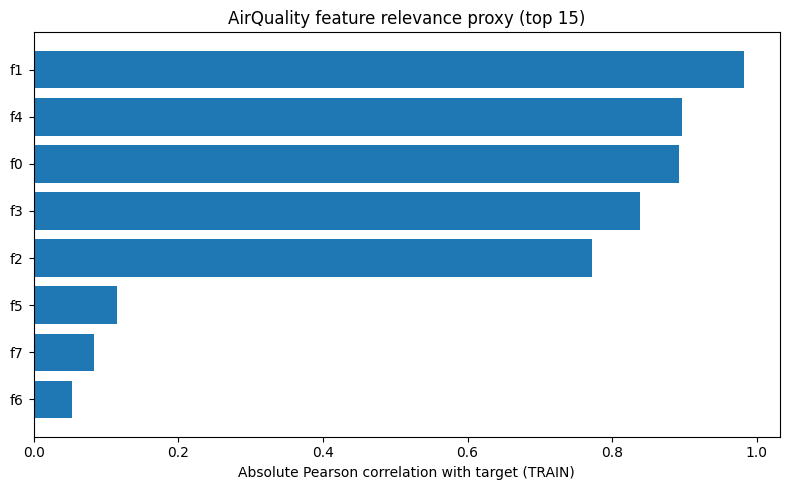

Saved: figures/airquality_feature_relevance.pdf


,feature,abs_corr
0,f1,0.982971
1,f4,0.896256
2,f0,0.892003
3,f3,0.839041
4,f2,0.771494
5,f5,0.114831
6,f7,0.083109
7,f6,0.053098


In [10]:
# --- Export: AirQuality feature relevance proxy (abs correlation with target, TRAIN only) ---
os.makedirs("figures", exist_ok=True)

# Required arrays from your preprocessing section
if "X_aq_train" not in globals() or "y_aq_train_np" not in globals():
    raise NameError("X_aq_train and/or y_aq_train_np not found. Run the AirQuality preprocessing/split first.")

X = np.asarray(X_aq_train, dtype=float)
y = np.asarray(y_aq_train_np, dtype=float).reshape(-1)

# Try to get feature names (preferred)
feature_names = None

# 1) If you already defined them
if "feature_names_aq" in globals():
    feature_names = list(feature_names_aq)

# 2) Otherwise try to infer from the fitted preprocessor
elif "aq_preprocess" in globals():
    try:
        feature_names = list(aq_preprocess.get_feature_names_out())
    except Exception:
        feature_names = None

# Fallback: generic names
if feature_names is None:
    feature_names = [f"f{i}" for i in range(X.shape[1])]

# Compute Pearson correlation per feature on TRAIN
# corr(x_j, y) = cov(x_j,y)/(std(x_j)std(y))
# Handle zero-variance features safely.
y_std = np.std(y)
corrs = []
for j in range(X.shape[1]):
    xj = X[:, j]
    sx = np.std(xj)
    if sx < 1e-12 or y_std < 1e-12:
        corrs.append(0.0)
    else:
        corrs.append(float(np.corrcoef(xj, y)[0, 1]))

abs_corr = np.abs(np.array(corrs))

# Make a nice table and plot top-k
df_imp = pd.DataFrame({
    "feature": feature_names,
    "abs_corr": abs_corr
}).sort_values("abs_corr", ascending=False).reset_index(drop=True)

top_k = 15
df_top = df_imp.head(top_k).iloc[::-1]  # reverse for horizontal bar plot (largest at top visually)

plt.figure(figsize=(8, 5))
plt.barh(df_top["feature"], df_top["abs_corr"])
plt.xlabel("Absolute Pearson correlation with target (TRAIN)")
plt.title(f"AirQuality feature relevance proxy (top {top_k})")
plt.tight_layout()

plt.savefig("figures/airquality_feature_relevance.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/airquality_feature_relevance.pdf")
display(df_imp.head(20))


In [11]:
# AirQuality - Tabular Autoencoder with bottleneck = d_aq
# The goal is to learn a compact latent representation (dimension d_aq) that reconstructs the original standardized features

# Train the autoencoder using training data for fitting and validation data for early stopping
# - bottleneck_dim=d_aq: size of the latent space (same dimensionality used for PCA comparison)
# - max_epochs=100: upper bound on training epochs
# - patience=10: early stopping patience (stop if val loss doesn't improve for 10 checks/epochs)
# - lr=1e-3: learning rate for the optimizer
# - batch_size=256: mini-batch size
# - print_every=20: logging frequency
ae_aq = train_tabular_ae(
    X_aq_train, X_aq_val,
    bottleneck_dim=d_aq,
    max_epochs=100,
    patience=10,
    lr=1e-3,
    batch_size=256,
    print_every=20
)

# Encode the datasets into the learned latent space using the AE encoder
# Important: we do NOT retrain here; we just apply the trained encoder
X_aq_train_ae = encode_tabular_ae(ae_aq, X_aq_train)
X_aq_val_ae   = encode_tabular_ae(ae_aq, X_aq_val)
X_aq_test_ae  = encode_tabular_ae(ae_aq, X_aq_test)

# Standardize the latent features as well
# Fit ONLY on the training latent representations to avoid leakage, then apply the same scaling to validation and test
scaler_ae = StandardScaler()
X_aq_train_ae = scaler_ae.fit_transform(X_aq_train_ae)
X_aq_val_ae   = scaler_ae.transform(X_aq_val_ae)
X_aq_test_ae  = scaler_ae.transform(X_aq_test_ae)

# Sanity check: each split should now have shape (n_samples, d_aq)
print("AE shapes:", X_aq_train_ae.shape, X_aq_val_ae.shape, X_aq_test_ae.shape)

AE epoch 001 | train MSE 0.774737 | val MSE 0.666012
AE epoch 020 | train MSE 0.004472 | val MSE 0.011363
AE epoch 040 | train MSE 0.002829 | val MSE 0.008385
Early stop @ epoch 54 (best val MSE 0.007018)
AE shapes: (6293, 6) (1349, 6) (1349, 6)


In [12]:
# --- train 3 regressors (Feed-Forward Neural Network) ---
# Hyper-parameter selection via TimeSeries cross-validation (TRAIN only),
# then final training with early-stopping on VAL, and evaluation on TEST.

# -----------------------------
# Reproducibility helper
# -----------------------------
def set_all_seeds(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds(SEED)

# -----------------------------
# Flexible FNN regressor (tunable depth/width)
# -----------------------------
class FNNRegressorHP(nn.Module):
    def __init__(self, in_dim: int, hidden=(64, 32), dropout: float = 0.0):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout and dropout > 0:
                layers += [nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Train with early stopping (returns history + time)
# -----------------------------
def train_fnn_regressor_hp(
    Xtr_np, ytr_np,
    Xva_np, yva_np,
    hidden=(64, 32),
    dropout=0.0,
    lr=1e-3,
    weight_decay=0.0,
    batch_size=512,
    max_epochs=200,
    patience=15,
    print_every=None,  # set to e.g. 50 for final training; keep None for CV (silent)
):
    Xtr = torch.tensor(Xtr_np, dtype=torch.float32)
    ytr = torch.tensor(ytr_np.reshape(-1, 1), dtype=torch.float32)
    Xva = torch.tensor(Xva_np, dtype=torch.float32)
    yva = torch.tensor(yva_np.reshape(-1, 1), dtype=torch.float32)

    tr_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(TensorDataset(Xva, yva), batch_size=batch_size, shuffle=False)

    model = FNNRegressorHP(in_dim=Xtr.shape[1], hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    bad = 0

    hist_tr, hist_va = [], []

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        # ---- train ----
        model.train()
        tr_sum = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            tr_sum += loss.item() * xb.size(0)
        tr_mse = tr_sum / len(tr_loader.dataset)

        # ---- val ----
        model.eval()
        va_sum = 0.0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                va_sum += loss_fn(model(xb), yb).item() * xb.size(0)
        va_mse = va_sum / len(va_loader.dataset)

        hist_tr.append(tr_mse)
        hist_va.append(va_mse)

        # Print ONLY if requested (keeps CV silent)
        if (print_every is not None) and (epoch % print_every == 0):
            print(f"Reg epoch {epoch:03d} | train MSE {tr_mse:.6f} | val MSE {va_mse:.6f}")

        # ---- early stopping ----
        if va_mse < best_val - 1e-8:
            best_val = va_mse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    elapsed = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, np.array(hist_tr), np.array(hist_va), float(elapsed), float(best_val)

# -----------------------------
# CV selection on TRAIN only (chronology preserved)
# -----------------------------
def select_fnn_hparams_timeseries_cv(
    Xtr_np, ytr_np,
    param_grid,
    n_splits=3,
    max_epochs_cv=60,   # lower for speed (still a valid CV)
    patience_cv=8,
    batch_size=512,
):
    tscv = TimeSeriesSplit(n_splits=n_splits)  # time-series CV: preserves order, avoids leakage
    rows = []

    for params in param_grid:
        rmses = []
        for fold, (idx_tr, idx_va) in enumerate(tscv.split(Xtr_np), 1):
            set_all_seeds(SEED + fold)

            _, _, _, _, best_val_mse = train_fnn_regressor_hp(
                Xtr_np[idx_tr], ytr_np[idx_tr],
                Xtr_np[idx_va], ytr_np[idx_va],
                hidden=params["hidden"],
                dropout=params["dropout"],
                lr=params["lr"],
                weight_decay=params["weight_decay"],
                batch_size=batch_size,
                max_epochs=max_epochs_cv,
                patience=patience_cv,
                print_every=None,  # IMPORTANT: keep CV silent
            )
            rmses.append(np.sqrt(best_val_mse))

        rows.append({
            **params,
            "cv_rmse_mean": float(np.mean(rmses)),
            "cv_rmse_std": float(np.std(rmses)),
        })

    cv_df = pd.DataFrame(rows).sort_values("cv_rmse_mean").reset_index(drop=True)
    best_params = cv_df.iloc[0][["hidden", "dropout", "lr", "weight_decay"]].to_dict()
    return best_params, cv_df

# -----------------------------
# Small hyper-parameter grid (fast but meaningful)
# -----------------------------
param_grid_fnn = [
    {"hidden": (64, 32),  "dropout": 0.0, "lr": 1e-3, "weight_decay": 0.0},
    {"hidden": (64, 32),  "dropout": 0.0, "lr": 1e-3, "weight_decay": 1e-4},
    {"hidden": (64, 32),  "dropout": 0.0, "lr": 5e-4, "weight_decay": 0.0},
    {"hidden": (64, 32),  "dropout": 0.0, "lr": 5e-4, "weight_decay": 1e-4},
    {"hidden": (128, 64), "dropout": 0.0, "lr": 1e-3, "weight_decay": 0.0},
    {"hidden": (128, 64), "dropout": 0.0, "lr": 1e-3, "weight_decay": 1e-4},
    {"hidden": (128, 64), "dropout": 0.0, "lr": 5e-4, "weight_decay": 0.0},
    {"hidden": (128, 64), "dropout": 0.0, "lr": 5e-4, "weight_decay": 1e-4},
]

# -----------------------------
# 1) ORIGINAL features — CV on TRAIN
# -----------------------------
print("\n[AirQuality FNN] Hyper-parameter selection (TimeSeries CV) — ORIGINAL")
best_hp_orig, cv_fnn_orig = select_fnn_hparams_timeseries_cv(
    X_aq_train, y_aq_train_np,
    param_grid_fnn,
    n_splits=3
)
display(cv_fnn_orig.head(10))
print("Best HP (ORIGINAL):", best_hp_orig)

print("\nTraining FNN on ORIGINAL (final, early-stop on VAL)...")
reg_orig, tr_fnn_orig, va_fnn_orig, t_fnn_orig, _ = train_fnn_regressor_hp(
    X_aq_train, y_aq_train_np,
    X_aq_val,   y_aq_val_np,
    **best_hp_orig,
    batch_size=512,
    max_epochs=200,
    patience=15,
    print_every=50
)

# -----------------------------
# 2) PCA features — CV on TRAIN
# -----------------------------
print("\n[AirQuality FNN] Hyper-parameter selection (TimeSeries CV) — PCA")
best_hp_pca, cv_fnn_pca = select_fnn_hparams_timeseries_cv(
    X_aq_train_pca, y_aq_train_np,
    param_grid_fnn,
    n_splits=3
)
display(cv_fnn_pca.head(10))
print("Best HP (PCA):", best_hp_pca)

print("\nTraining FNN on PCA (final, early-stop on VAL)...")
reg_pca, tr_fnn_pca, va_fnn_pca, t_fnn_pca, _ = train_fnn_regressor_hp(
    X_aq_train_pca, y_aq_train_np,
    X_aq_val_pca,   y_aq_val_np,
    **best_hp_pca,
    batch_size=512,
    max_epochs=200,
    patience=15,
    print_every=50
)

# -----------------------------
# 3) AE latent features — CV on TRAIN
# -----------------------------
print("\n[AirQuality FNN] Hyper-parameter selection (TimeSeries CV) — AE")
best_hp_ae, cv_fnn_ae = select_fnn_hparams_timeseries_cv(
    X_aq_train_ae, y_aq_train_np,
    param_grid_fnn,
    n_splits=3
)
display(cv_fnn_ae.head(10))
print("Best HP (AE):", best_hp_ae)

print("\nTraining FNN on AE (final, early-stop on VAL)...")
reg_ae, tr_fnn_ae, va_fnn_ae, t_fnn_ae, _ = train_fnn_regressor_hp(
    X_aq_train_ae, y_aq_train_np,
    X_aq_val_ae,   y_aq_val_np,
    **best_hp_ae,
    batch_size=512,
    max_epochs=200,
    patience=15,
    print_every=50
)

# -----------------------------
# Evaluate on TEST (final models)
# -----------------------------
pred_orig = predict_regressor(reg_orig, X_aq_test)
pred_pca  = predict_regressor(reg_pca,  X_aq_test_pca)
pred_ae   = predict_regressor(reg_ae,   X_aq_test_ae)

results_aq = pd.DataFrame([
    {"repr": "original", "train_time_s": t_fnn_orig, **eval_regression(y_aq_test_np, pred_orig)},
    {"repr": "pca",      "train_time_s": t_fnn_pca,  **eval_regression(y_aq_test_np, pred_pca)},
    {"repr": "ae",       "train_time_s": t_fnn_ae,   **eval_regression(y_aq_test_np, pred_ae)},
]).sort_values("RMSE")

results_aq_rounded = results_aq.copy()
for col in ["MSE", "MAE", "RMSE", "R2", "train_time_s"]:
    if col in results_aq_rounded.columns:
        results_aq_rounded[col] = results_aq_rounded[col].astype(float).round(4)

print("\nAirQuality regression — TEST metrics (final models)")
display(results_aq_rounded)

best_hp_fnn = {"original": best_hp_orig, "pca": best_hp_pca, "ae": best_hp_ae}
print("\nSelected hyper-parameters (FNN AirQuality):")
print(best_hp_fnn)



[AirQuality FNN] Hyper-parameter selection (TimeSeries CV) — ORIGINAL


,hidden,dropout,lr,weight_decay,cv_rmse_mean,cv_rmse_std
0,"(128, 64)",0.0,0.0010,0.0000,1.322247,0.334995
1,"(128, 64)",0.0,0.0010,0.0001,1.369739,0.392492
2,"(64, 32)",0.0,0.0010,0.0001,1.709314,0.327792
3,"(64, 32)",0.0,0.0010,0.0000,1.744462,0.346202
4,"(128, 64)",0.0,0.0005,0.0000,1.774566,0.433721
5,"(128, 64)",0.0,0.0005,0.0001,1.806783,0.451061
6,"(64, 32)",0.0,0.0005,0.0001,2.614983,0.848069
7,"(64, 32)",0.0,0.0005,0.0000,2.633854,0.875437


Best HP (ORIGINAL): {'hidden': (128, 64), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0}

Training FNN on ORIGINAL (final, early-stop on VAL)...
Reg epoch 050 | train MSE 0.195799 | val MSE 0.336079
Reg epoch 100 | train MSE 0.041810 | val MSE 0.067823
Reg epoch 150 | train MSE 0.020205 | val MSE 0.059341

[AirQuality FNN] Hyper-parameter selection (TimeSeries CV) — PCA


,hidden,dropout,lr,weight_decay,cv_rmse_mean,cv_rmse_std
0,"(128, 64)",0.0,0.0010,0.0001,1.908511,0.323441
1,"(128, 64)",0.0,0.0010,0.0000,1.929624,0.333377
2,"(64, 32)",0.0,0.0010,0.0001,2.180924,0.423945
3,"(64, 32)",0.0,0.0010,0.0000,2.182248,0.423468
4,"(128, 64)",0.0,0.0005,0.0001,2.334653,0.224720
5,"(128, 64)",0.0,0.0005,0.0000,2.351430,0.234188
6,"(64, 32)",0.0,0.0005,0.0001,3.746863,0.580719
7,"(64, 32)",0.0,0.0005,0.0000,3.755164,0.573931


Best HP (PCA): {'hidden': (128, 64), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0001}

Training FNN on PCA (final, early-stop on VAL)...
Reg epoch 050 | train MSE 0.977364 | val MSE 1.748364

[AirQuality FNN] Hyper-parameter selection (TimeSeries CV) — AE


,hidden,dropout,lr,weight_decay,cv_rmse_mean,cv_rmse_std
0,"(128, 64)",0.0,0.0010,0.0000,1.462595,0.163191
1,"(128, 64)",0.0,0.0010,0.0001,1.465097,0.166627
2,"(64, 32)",0.0,0.0010,0.0000,1.652727,0.198417
3,"(64, 32)",0.0,0.0010,0.0001,1.655008,0.213503
4,"(128, 64)",0.0,0.0005,0.0000,1.706500,0.195206
5,"(128, 64)",0.0,0.0005,0.0001,1.729765,0.237002
6,"(64, 32)",0.0,0.0005,0.0001,2.622968,0.756895
7,"(64, 32)",0.0,0.0005,0.0000,2.656491,0.730678


Best HP (AE): {'hidden': (128, 64), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0}

Training FNN on AE (final, early-stop on VAL)...
Reg epoch 050 | train MSE 0.743807 | val MSE 1.959010
Reg epoch 100 | train MSE 0.575361 | val MSE 1.532296
Reg epoch 150 | train MSE 0.490165 | val MSE 1.066699

AirQuality regression — TEST metrics (final models)


,repr,train_time_s,MSE,MAE,RMSE,R2
0,original,13.3701,0.0985,0.2377,0.3138,0.9973
1,pca,5.5876,3.2379,1.6473,1.7994,0.9122
2,ae,12.6225,3.4573,1.5898,1.8594,0.9062



Selected hyper-parameters (FNN AirQuality):
{'original': {'hidden': (128, 64), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0}, 'pca': {'hidden': (128, 64), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0001}, 'ae': {'hidden': (128, 64), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0}}


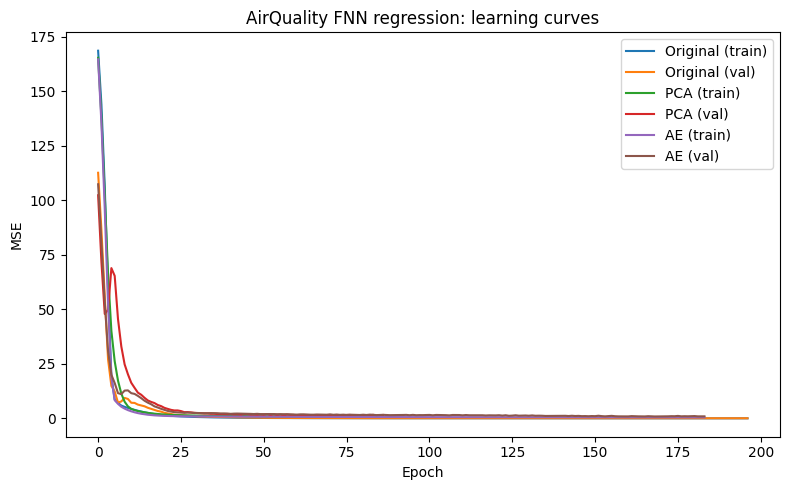

Saved: figures/airquality_learning_curves.pdf


In [13]:
# --- Export: AirQuality FNN learning curves (train vs val MSE) as PDF for the report ---
os.makedirs("figures", exist_ok=True)

required = [
    "tr_fnn_orig", "va_fnn_orig",
    "tr_fnn_pca",  "va_fnn_pca",
    "tr_fnn_ae",   "va_fnn_ae",
]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}. Run the AirQuality FNN training cell first.")

def _to_np(x):
    return np.asarray(x, dtype=float)

tr_o, va_o = _to_np(tr_fnn_orig), _to_np(va_fnn_orig)
tr_p, va_p = _to_np(tr_fnn_pca),  _to_np(va_fnn_pca)
tr_a, va_a = _to_np(tr_fnn_ae),   _to_np(va_fnn_ae)

plt.figure(figsize=(8, 5))

plt.plot(tr_o, label="Original (train)")
plt.plot(va_o, label="Original (val)")

plt.plot(tr_p, label="PCA (train)")
plt.plot(va_p, label="PCA (val)")

plt.plot(tr_a, label="AE (train)")
plt.plot(va_a, label="AE (val)")

plt.title("AirQuality FNN regression: learning curves")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()

plt.savefig("figures/airquality_learning_curves.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/airquality_learning_curves.pdf")


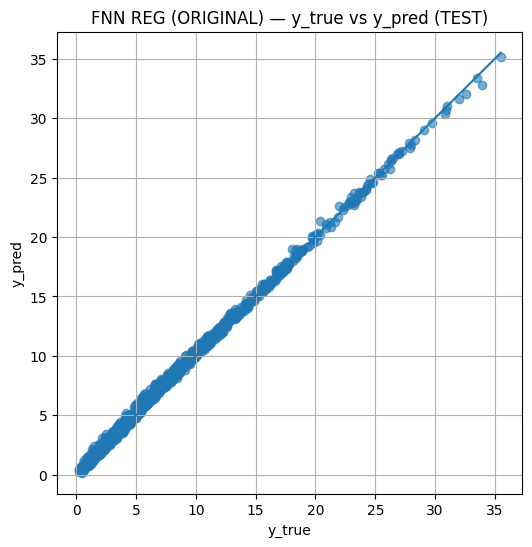

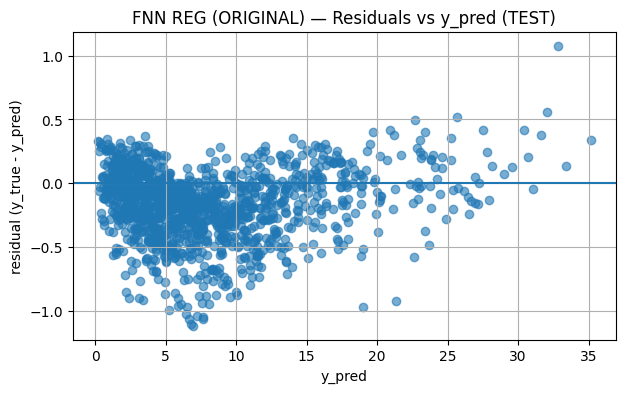

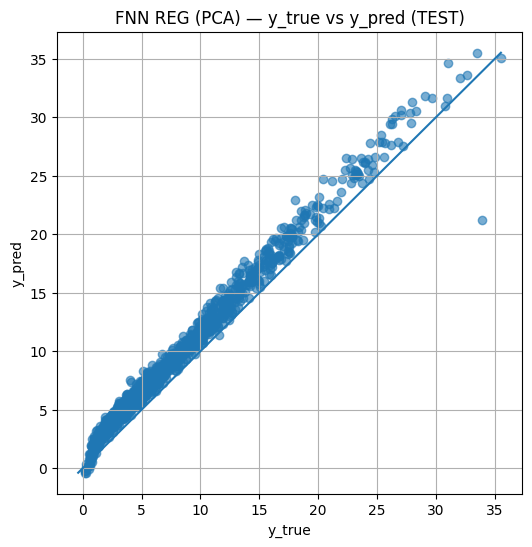

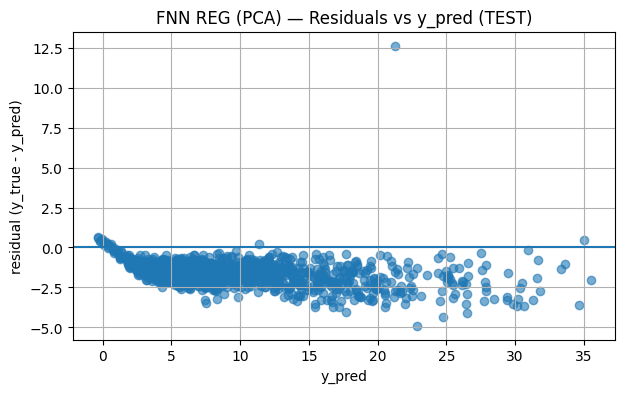

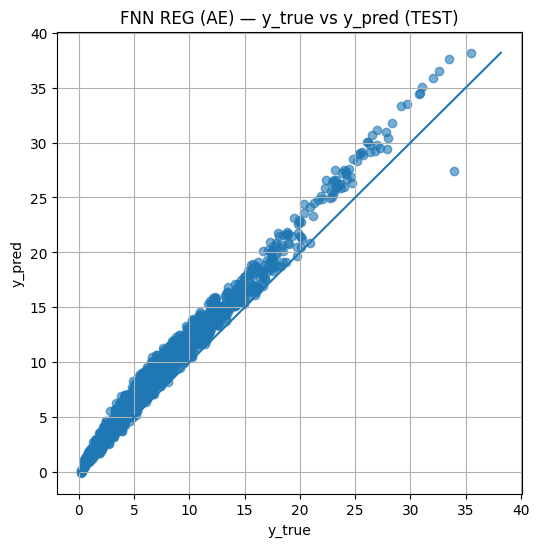

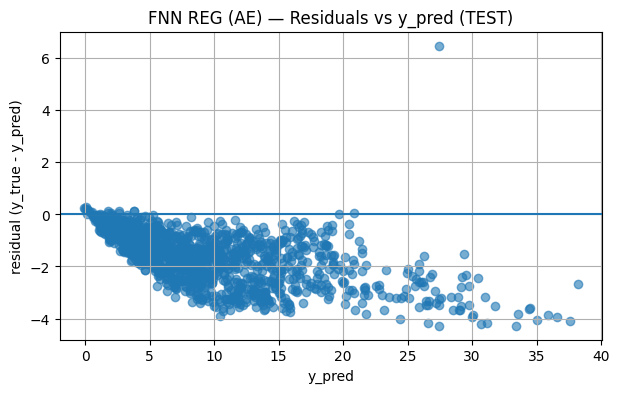

In [14]:
def plot_regression_diagnostics(y_true, y_pred, title_prefix=""):
    """
    Diagnostic plots on TEST:
    1) y_true vs y_pred (ideal line y=x)
    2) residuals vs y_pred
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    resid  = y_true - y_pred

    # --- Plot 1: y_true vs y_pred ---
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx])  # ideal line y=x
    plt.xlabel("y_true")
    plt.ylabel("y_pred")
    plt.title(f"{title_prefix} — y_true vs y_pred (TEST)")
    plt.grid(True)
    plt.show()

    # --- Plot 2: residuals vs y_pred ---
    plt.figure(figsize=(7, 4))
    plt.scatter(y_pred, resid, alpha=0.6)
    plt.axhline(0)  # zero residual reference
    plt.xlabel("y_pred")
    plt.ylabel("residual (y_true - y_pred)")
    plt.title(f"{title_prefix} — Residuals vs y_pred (TEST)")
    plt.grid(True)
    plt.show()


# Diagnostics for the three representations (TEST)
plot_regression_diagnostics(y_aq_test_np, pred_orig, "FNN REG (ORIGINAL)")
plot_regression_diagnostics(y_aq_test_np, pred_pca, "FNN REG (PCA)")
plot_regression_diagnostics(y_aq_test_np, pred_ae, "FNN REG (AE)")


In [15]:
# Choose the PCA latent dimension for the Paddy dataset
# (i.e., how many principal components to keep)
d_paddy = 10

# Initialize PCA:
# - n_components=d_paddy keeps the top 10 directions of maximum variance
# - random_state makes results reproducible when the solver involves randomness
pca_paddy = PCA(n_components=d_paddy, random_state=SEED)

# Fit PCA ONLY on the training data to avoid leakage (the components depend on data distribution)
# Then transform validation and test using the same learned components
X_paddy_train_pca = pca_paddy.fit_transform(X_paddy_train)
X_paddy_val_pca   = pca_paddy.transform(X_paddy_val)
X_paddy_test_pca  = pca_paddy.transform(X_paddy_test)

# Sanity check: shapes should be (n_samples_split, d_paddy)
print("Paddy PCA shapes:", X_paddy_train_pca.shape, X_paddy_val_pca.shape, X_paddy_test_pca.shape)

# Print how much total variance is explained by the retained components
# This indicates how much information (in terms of variance) PCA keeps
print("Explained variance total (raw):", pca_paddy.explained_variance_ratio_.sum())

# Same value printed with more digits for more precise reporting in a report
print("Explained variance total (more digits):", f"{pca_paddy.explained_variance_ratio_.sum():.12f}")

Paddy PCA shapes: (1636, 10) (351, 10) (351, 10)
Explained variance total (raw): 0.9998326049279049
Explained variance total (more digits): 0.999832604928


In [16]:
# Print the number of input features after preprocessing (scaling + one-hot encoding, etc.)
# This is the dimensionality of each training sample
print("n_features:", X_paddy_train.shape[1])

# Compute and print the (numerical) matrix rank of the training feature matrix
# The rank is the number of linearly independent columns (up to numerical tolerance),
# i.e., an estimate of the intrinsic linear dimensionality of the data.
# If rank << n_features, many features are redundant/collinear (common with one-hot encoding).
print("rank (approx):", np.linalg.matrix_rank(X_paddy_train))

n_features: 71
rank (approx): 12


In [17]:
# Paddy - Tabular Autoencoder with bottleneck = d_paddy
# The autoencoder learns a compact latent representation (dimension d_paddy)
# that can reconstruct the original preprocessed feature vectors

# Train the autoencoder using:
# - X_paddy_train for learning the parameters
# - X_paddy_val for validation and early stopping (to prevent overfitting)
# Key hyperparameters:
# - bottleneck_dim=d_paddy: size of the latent space (same dimension as PCA for comparison)
# - max_epochs=100: maximum training epochs
# - patience=10: early stopping patience on validation loss
# - lr=1e-3: learning rate
# - batch_size=256: mini-batch size
# - print_every=20: print training progress every 20 epochs/steps (depending on implementation)
ae_paddy = train_tabular_ae(
    X_paddy_train, X_paddy_val,
    bottleneck_dim=d_paddy,
    max_epochs=100,
    patience=10,
    lr=1e-3,
    batch_size=256,
    print_every=20
)

# Encode each split into the learned latent space using the trained encoder part of the AE
# We apply the same trained model to train/val/test (no refitting here)
X_paddy_train_ae = encode_tabular_ae(ae_paddy, X_paddy_train)
X_paddy_val_ae   = encode_tabular_ae(ae_paddy, X_paddy_val)
X_paddy_test_ae  = encode_tabular_ae(ae_paddy, X_paddy_test)

# Sanity check: each output should have shape (n_samples_split, d_paddy)
print("Paddy AE shapes:", X_paddy_train_ae.shape, X_paddy_val_ae.shape, X_paddy_test_ae.shape)

AE epoch 001 | train MSE 0.597006 | val MSE 0.566674
AE epoch 020 | train MSE 0.023591 | val MSE 0.023663
AE epoch 040 | train MSE 0.010925 | val MSE 0.010811
AE epoch 060 | train MSE 0.002400 | val MSE 0.002441
AE epoch 080 | train MSE 0.000714 | val MSE 0.000747
AE epoch 100 | train MSE 0.000449 | val MSE 0.000476
Paddy AE shapes: (1636, 10) (351, 10) (351, 10)


In [18]:
# Select the best number of clusters k using K-Fold CV on the TRAIN set (silhouette),
# then refit on train+val and evaluate silhouette on the TEST set.
# This mirrors a supervised workflow (model selection on train-CV, final eval on test),
# but using an unsupervised metric (silhouette).

def kmeans_objective_on_X(km, X):
    """
    K-Means objective (WCSS) computed on X using the centroids in km
    It assigns each point to its nearest centroid and sums squared distances
    """
    # km.transform(X) returns Euclidean distances to each centroid (shape: n_samples x k)
    D = km.transform(X)
    return float(np.sum(np.min(D, axis=1) ** 2))

def best_k_by_train_kfold_silhouette(Xtr, k_min=2, k_max=15, n_splits=3):
    """
    Cross-validation for KMeans hyperparameter selection (k):
    - Split TRAIN into K folds
    - For each k:
        * fit on K-1 folds
        * compute silhouette on the held-out fold
      then average the silhouette across folds
    - Return the k with the highest mean silhouette and a summary table
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    rows = []
    for k in range(k_min, k_max + 1):
        fold_scores = []

        for tr_idx, va_idx in kf.split(Xtr):
            X_tr_fold = Xtr[tr_idx]
            X_va_fold = Xtr[va_idx]

            km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
            km.fit(X_tr_fold)

            labels_va = km.predict(X_va_fold)
            fold_scores.append(silhouette_score(X_va_fold, labels_va))

        rows.append({
            "k": k,
            "silhouette_mean": float(np.mean(fold_scores)),
            "silhouette_std": float(np.std(fold_scores))
        })

    results_df = pd.DataFrame(rows).sort_values("silhouette_mean", ascending=False).reset_index(drop=True)
    best_k = int(results_df.loc[0, "k"])
    best_s = float(results_df.loc[0, "silhouette_mean"])
    return best_k, best_s, results_df


def fit_final_and_test(Xtr, Xva, Xte, k):
    """
    Final training + test evaluation:
    - Refit KMeans with the chosen k on (train + validation)
    - Predict labels for test data
    - Compute and return silhouette score on the test set
    """
    Xfit = np.vstack([Xtr, Xva])  # use more data for the final model
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    km.fit(Xfit)

    labels_te = km.predict(Xte)
    s_test = silhouette_score(Xte, labels_te)
    return s_test

def fit_final_and_test_metrics(Xtr, Xva, Xte, k):
    """
    Fit on train+val, evaluate on test:
    - silhouette (higher is better)
    - objective/WCSS (lower is better)
    Also returns normalized objective values for fairer comparison
    """
    Xfit = np.vstack([Xtr, Xva])

    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    km.fit(Xfit)

    # Silhouette on TEST
    labels_te = km.predict(Xte)
    sil_te = float(silhouette_score(Xte, labels_te))

    # Objective (WCSS) on TEST
    obj_te = kmeans_objective_on_X(km, Xte)

    # Normalizations
    obj_te_per_sample = obj_te / Xte.shape[0]
    obj_te_per_sample_per_dim = obj_te / (Xte.shape[0] * Xte.shape[1])

    return sil_te, obj_te, obj_te_per_sample, obj_te_per_sample_per_dim


# -----------------------------
# Choose k via K-Fold CV on TRAIN (for each representation)
# -----------------------------

# Original feature space (after preprocessing)
k_orig, s_orig, table_orig = best_k_by_train_kfold_silhouette(X_paddy_train, k_min=2, k_max=15, n_splits=3)

# PCA latent space
k_pca, s_pca, table_pca = best_k_by_train_kfold_silhouette(X_paddy_train_pca, k_min=2, k_max=15, n_splits=3)

# Autoencoder latent space
k_ae, s_ae, table_ae = best_k_by_train_kfold_silhouette(X_paddy_train_ae, k_min=2, k_max=15, n_splits=3)

# Print best k and its mean CV silhouette (computed via K-Fold on TRAIN) for each representation
print("Best k (3-fold CV on TRAIN):")
print("- ORIG:", (k_orig, s_orig))
print("- PCA:", (k_pca,  s_pca))
print("- AE:", (k_ae,   s_ae))

# -----------------------------
# Final evaluation on TEST (refit on train+val, then test once)
# -----------------------------
rows = []

sil, obj, obj_ps, obj_psd = fit_final_and_test_metrics(
    X_paddy_train, X_paddy_val, X_paddy_test, k_orig
)
rows.append({"repr": "ORIG", "k": k_orig, "silhouette_test": sil,
             "objective_test": obj, "obj_per_sample": obj_ps, "obj_per_sample_per_dim": obj_psd})

sil, obj, obj_ps, obj_psd = fit_final_and_test_metrics(
    X_paddy_train_pca, X_paddy_val_pca, X_paddy_test_pca, k_pca
)
rows.append({"repr": "PCA", "k": k_pca, "silhouette_test": sil,
             "objective_test": obj, "obj_per_sample": obj_ps, "obj_per_sample_per_dim": obj_psd})

sil, obj, obj_ps, obj_psd = fit_final_and_test_metrics(
    X_paddy_train_ae, X_paddy_val_ae, X_paddy_test_ae, k_ae
)
rows.append({"repr": "AE", "k": k_ae, "silhouette_test": sil,
             "objective_test": obj, "obj_per_sample": obj_ps, "obj_per_sample_per_dim": obj_psd})

df_kmeans_metrics = pd.DataFrame(rows)

# Show both silhouette (higher is better) and objective/WCSS (lower is better)
display(df_kmeans_metrics.sort_values("silhouette_test", ascending=False))


Best k (3-fold CV on TRAIN):
- ORIG: (12, 0.5220324990717925)
- PCA: (12, 0.5223233220006251)
- AE: (6, 0.5514804720878601)


,repr,k,silhouette_test,objective_test,obj_per_sample,obj_per_sample_per_dim
2,AE,6,0.558438,1248.635620,3.557366,0.355737
1,PCA,12,0.533009,1549.173073,4.413598,0.441360
0,ORIG,12,0.532722,1551.405317,4.419958,0.062253


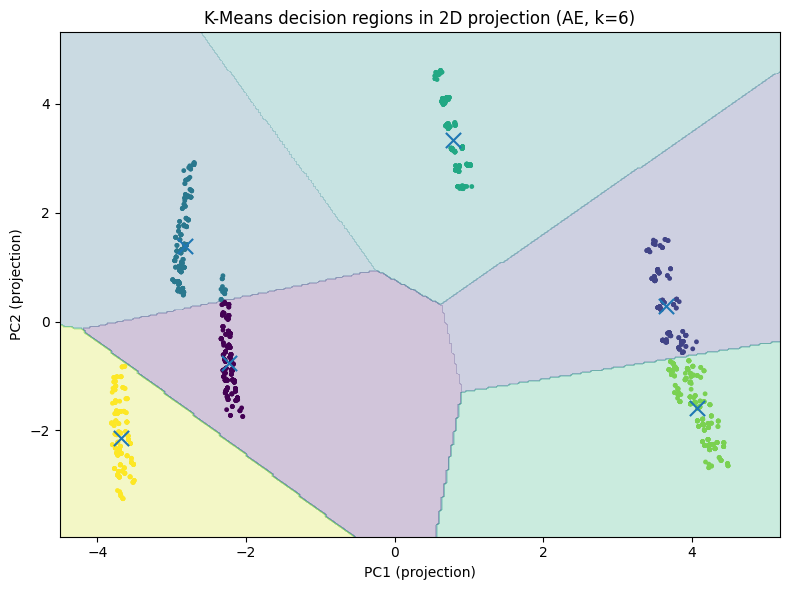

Saved: figures/kmeans_decision_regions_2d.pdf


In [19]:
# --- Export: KMeans decision regions in a 2D projection (recommended: AE representation) ---
os.makedirs("figures", exist_ok=True)

# We visualize AE because it performed best. Requirements:
# - X_paddy_train_ae must exist (AE latent features for TRAIN)
# - k_ae or df_kmeans_metrics must exist to determine k

if "X_paddy_train_ae" not in globals():
    raise NameError("X_paddy_train_ae not found. Run the Paddy AE encoding section first.")

# Determine k for AE
k_vis = None
if "k_ae" in globals():
    k_vis = int(k_ae)
elif "df_kmeans_metrics" in globals():
    # try to read k for AE from the summary table
    tmp = df_kmeans_metrics.copy()
    if "repr" in tmp.columns:
        tmp["repr"] = tmp["repr"].str.lower()
        row = tmp[tmp["repr"].isin(["ae", "ae_latent", "autoencoder"])].head(1)
        if len(row) > 0 and "k" in row.columns:
            k_vis = int(row["k"].values[0])
if k_vis is None:
    raise NameError("Could not determine k for AE. Ensure k_ae exists or df_kmeans_metrics contains the AE row with column 'k'.")

X = X_paddy_train_ae
X = np.asarray(X)

# 2D projection for visualization
pca2 = PCA(n_components=2, random_state=SEED)
X2 = pca2.fit_transform(X)

# Fit KMeans in 2D (for clean Voronoi-like regions in the plot)
km2 = KMeans(n_clusters=k_vis, n_init=10, random_state=SEED)
labels2 = km2.fit_predict(X2)

# Create a mesh grid over the 2D space
pad = 0.7
x_min, x_max = X2[:, 0].min() - pad, X2[:, 0].max() + pad
y_min, y_max = X2[:, 1].min() - pad, X2[:, 1].max() + pad

# Resolution controls the smoothness of regions (keep reasonable for speed)
res = 300
xx, yy = np.meshgrid(np.linspace(x_min, x_max, res),
                     np.linspace(y_min, y_max, res))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = km2.predict(grid).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X2[:, 0], X2[:, 1], c=labels2, s=12, edgecolors="none")
plt.scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1], marker="x", s=120)

plt.title(f"K-Means decision regions in 2D projection (AE, k={k_vis})")
plt.xlabel("PC1 (projection)")
plt.ylabel("PC2 (projection)")
plt.tight_layout()

plt.savefig("figures/kmeans_decision_regions_2d.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/kmeans_decision_regions_2d.pdf")

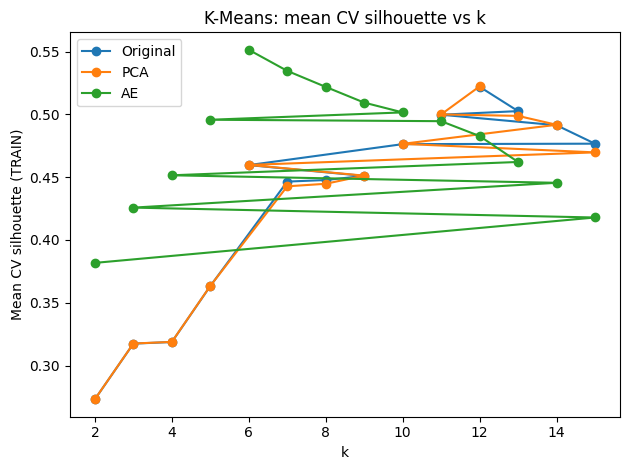

Saved: figures/kmeans_silhouette_vs_k.pdf


In [20]:
# --- Export: KMeans CV silhouette vs k (Original vs PCA vs AE) as PDF for the report ---
os.makedirs("figures", exist_ok=True)

# Sanity checks: these should exist from the KMeans CV selection cell
required = ["table_orig", "table_pca", "table_ae"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}. Run the KMeans k-selection (CV on TRAIN) cell first.")

def _get_k_and_score(df):
    # Handles common column names
    dfc = df.copy()
    cols = [c.lower() for c in dfc.columns]
    dfc.columns = cols

    # expected: 'k' and something like 'mean_silhouette' or 'silhouette_mean'
    if "k" not in dfc.columns:
        raise ValueError("Expected a column named 'k' in the CV table.")
    score_col = None
    for cand in ["mean_silhouette", "silhouette_mean", "mean_sil", "sil_mean", "mean_score", "score_mean"]:
        if cand in dfc.columns:
            score_col = cand
            break
    if score_col is None:
        # fallback: take the first non-k numeric column
        num_cols = [c for c in dfc.columns if c != "k"]
        if len(num_cols) == 0:
            raise ValueError("Could not find a silhouette mean column in the CV table.")
        score_col = num_cols[0]

    return dfc["k"].values, dfc[score_col].values, score_col

k1, s1, c1 = _get_k_and_score(table_orig)
k2, s2, c2 = _get_k_and_score(table_pca)
k3, s3, c3 = _get_k_and_score(table_ae)

plt.figure()
plt.plot(k1, s1, marker="o", label="Original")
plt.plot(k2, s2, marker="o", label="PCA")
plt.plot(k3, s3, marker="o", label="AE")
plt.xlabel("k")
plt.ylabel("Mean CV silhouette (TRAIN)")
plt.title("K-Means: mean CV silhouette vs k")
plt.legend()
plt.tight_layout()

plt.savefig("figures/kmeans_silhouette_vs_k.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/kmeans_silhouette_vs_k.pdf")


In [21]:
# Image size used for representation learning (PCA / Autoencoder) on RealWaste
# Smaller images (e.g., 64x64) reduce dimensionality and training time
IMG_DR = 64

# Batch size for PyTorch DataLoaders
BS_RW = 64

# -----------------------------
# Base transforms (no augmentation):
# - Resize all images to a fixed resolution (IMG_DR x IMG_DR)
# - Convert to tensor in [0, 1]
# This is typically used when you want stable, comparable inputs for PCA/AE
# -----------------------------
base_tf = transforms.Compose([
    transforms.Resize((IMG_DR, IMG_DR)),
    transforms.ToTensor(),  # converts PIL image to torch tensor, scales pixel values to [0,1]
])

# Build the full dataset with the base transforms applied
rw_base_ds = ImageFolder(root=realwaste_root, transform=base_tf)

# Create train/val/test subsets using the precomputed stratified indices
rw_train = Subset(rw_base_ds, train_idx)
rw_val   = Subset(rw_base_ds, val_idx)
rw_test  = Subset(rw_base_ds, test_idx)

# Create DataLoaders to iterate over the subsets in mini-batches.
# shuffle=False because:
# - for PCA/AE feature extraction it isn't necessary
# - and indices already define the split; keeping deterministic order can be convenient
# num_workers=2 enables parallel data loading (speeds up I/O on many systems)
rw_train_loader = DataLoader(rw_train, batch_size=BS_RW, shuffle=False, num_workers=2)
rw_val_loader   = DataLoader(rw_val, batch_size=BS_RW, shuffle=False, num_workers=2)
rw_test_loader  = DataLoader(rw_test, batch_size=BS_RW, shuffle=False, num_workers=2)

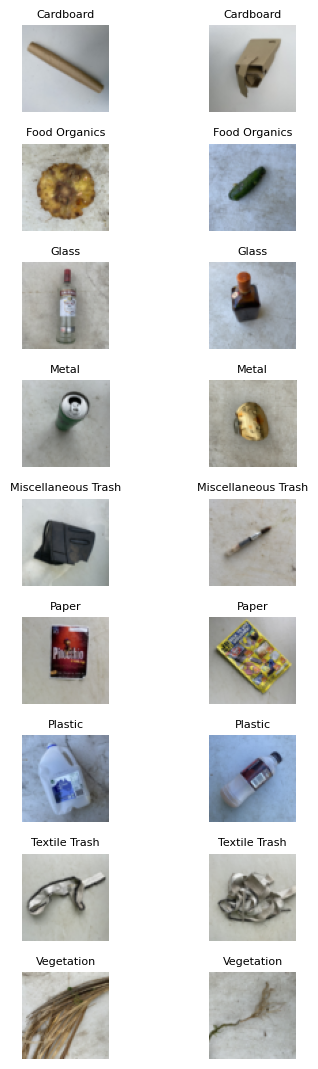

Saved: figures/realwaste_samples.pdf (download it from the Colab file browser)


In [22]:
# --- Export example RealWaste images (one grid) as PDF for the report ---
os.makedirs("figures", exist_ok=True)

ds = rw_base_ds
class_names = ds.classes
n_classes = len(class_names)

per_class = 2  # images per class in the grid
picked = {c: 0 for c in range(n_classes)}
images, labels = [], []

np.random.seed(SEED)

# Collect a few examples per class (deterministic scan)
for idx in range(len(ds)):
    img, y = ds[idx]  # img is a Tensor in [0,1], shape CxHxW
    if picked[y] < per_class:
        images.append(img)
        labels.append(y)
        picked[y] += 1
    if all(picked[c] >= per_class for c in range(n_classes)):
        break

rows = n_classes
cols = per_class
plt.figure(figsize=(cols * 2.4, rows * 1.2))

for i, (img, y) in enumerate(zip(images, labels), 1):
    ax = plt.subplot(rows, cols, i)
    im = img.permute(1, 2, 0).numpy()  # CxHxW -> HxWxC
    im = np.clip(im, 0, 1)
    ax.imshow(im)
    ax.set_title(class_names[y], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("figures/realwaste_samples.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/realwaste_samples.pdf (download it from the Colab file browser)")


In [23]:
# Utility: load the entire dataset from a DataLoader into two big tensors (X, Y)
# This is convenient for PCA/AE experiments where we want the full matrix in memory
def collect_xy(loader):
    xs, ys = [], []
    for x, y in loader:
        xs.append(x)  # x has shape (B, C, H, W)
        ys.append(y)  # y has shape (B,)
    # Concatenate all batches along the sample dimension
    X = torch.cat(xs, dim=0)  # (N, C, H, W)
    Y = torch.cat(ys, dim=0)  # (N,)
    return X, Y

# Collect train/val/test tensors from their loaders
Xrw_tr, yrw_tr = collect_xy(rw_train_loader)
Xrw_va, yrw_va = collect_xy(rw_val_loader)
Xrw_te, yrw_te = collect_xy(rw_test_loader)

# -----------------------------
# Flatten images for PCA:
# PCA expects a 2D matrix (n_samples, n_features)
# Each image (C,H,W) is flattened to a 1D vector of length C*H*W
# -----------------------------
Xtr_flat = Xrw_tr.view(Xrw_tr.size(0), -1).numpy()
Xva_flat = Xrw_va.view(Xrw_va.size(0), -1).numpy()
Xte_flat = Xrw_te.view(Xrw_te.size(0), -1).numpy()

# Latent dimension used for both PCA and the Autoencoder (for fair comparison)
d_rw = 128

# -----------------------------
# PCA training and encoding
# Fit PCA ONLY on training data to avoid leakage.
# Then encode validation/test using the learned components.
# -----------------------------
pca_rw = PCA(n_components=d_rw, random_state=SEED)
Ztr = pca_rw.fit_transform(Xtr_flat)  # low-dim representation of train images
Zva = pca_rw.transform(Xva_flat)      # low-dim representation of val images
Zte = pca_rw.transform(Xte_flat)      # low-dim representation of test images

# -----------------------------
# Reconstruction via inverse PCA:
# Map latent vectors back to the original pixel space to obtain reconstructed images
# This is useful to visualize how much information PCA retains
# -----------------------------
Xtr_pca = pca_rw.inverse_transform(Ztr)
Xva_pca = pca_rw.inverse_transform(Zva)
Xte_pca = pca_rw.inverse_transform(Zte)

# -----------------------------
# Reshape back to image format and clip values:
# - reshape to (N, 3, IMG_DR, IMG_DR)
# - clip to [0, 1] because inverse PCA may produce values outside the valid pixel range
# -----------------------------
Xtr_pca = np.clip(Xtr_pca.reshape(-1, 3, IMG_DR, IMG_DR), 0, 1)
Xva_pca = np.clip(Xva_pca.reshape(-1, 3, IMG_DR, IMG_DR), 0, 1)
Xte_pca = np.clip(Xte_pca.reshape(-1, 3, IMG_DR, IMG_DR), 0, 1)

# Sanity checks:
# - reconstructed arrays should match original image shapes
# - explained variance indicates how much of the dataset variance is kept by d_rw components
print("RW PCA recon:", Xtr_pca.shape, Xva_pca.shape, Xte_pca.shape)
print("RW PCA explained variance:", float(pca_rw.explained_variance_ratio_.sum()))

RW PCA recon: (3326, 3, 64, 64) (713, 3, 64, 64) (713, 3, 64, 64)
RW PCA explained variance: 0.8821824789047241


In [24]:
# Batch size for RealWaste experiments (64 images per mini-batch)
BS_RW = 64

# -----------------------------
# Build DataLoaders from in-memory tensors (already loaded with collect_xy)
# We wrap (X, y) into a TensorDataset, then create loaders for training/evaluation
# -----------------------------

# Training loader:
# shuffle=True to randomize mini-batches each epoch (helps SGD optimization and generalization)
train_loader_orig64 = DataLoader(
    TensorDataset(Xrw_tr, yrw_tr),
    batch_size=BS_RW,
    shuffle=True
)

# Validation loader:
# shuffle=False to keep deterministic ordering
val_loader_orig64 = DataLoader(
    TensorDataset(Xrw_va, yrw_va),
    batch_size=BS_RW,
    shuffle=False
)

# Test loader:
# shuffle=False for consistent evaluation
test_loader_orig64 = DataLoader(
    TensorDataset(Xrw_te, yrw_te),
    batch_size=BS_RW,
    shuffle=False
)

# Sanity checks:
# - len(loader) gives the number of batches in each split
# - number of classes should match the dataset class list (ImageFolder classes)
print("Orig64 loaders ready:", len(train_loader_orig64), len(val_loader_orig64), len(test_loader_orig64))
print("Num classes:", len(rw_base_ds.classes))

Orig64 loaders ready: 52 12 12
Num classes: 9


In [25]:
# RealWaste Convolutional Autoencoder (64x64) with latent dimension = d_rw
# We train a ConvAE to reconstruct the input images;
# the bottleneck (latent space) is a compact representation that can be compared with PCA (same d_rw)

# Use pinned memory + AMP only when running on CUDA (GPU)
# - pin_memory speeds up host->GPU transfers
# - AMP (automatic mixed precision) speeds up training and reduces GPU memory usage
pin = (device == "cuda")
use_amp = (device == "cuda")

# Build loaders for AE training:
# For an autoencoder, the "labels" are the inputs themselves, so we pass (X, X)
# batch_size=256 is larger than the classifier batch size to speed up reconstruction training
ae_train_loader = DataLoader(
    TensorDataset(Xrw_tr, Xrw_tr),
    batch_size=256,
    shuffle=True,
    pin_memory=pin
)
ae_val_loader   = DataLoader(
    TensorDataset(Xrw_va, Xrw_va),
    batch_size=256,
    shuffle=False,
    pin_memory=pin
)

# -----------------------------
# ConvAE architecture for 64x64 RGB images
# Encoder: strided convolutions downsample spatially:
# 64x64 -> 32x32 -> 16x16 -> 8x8 -> 4x4
# Then flatten and map to a latent vector of size latent_dim
# Decoder: linear expansion + transposed convolutions to reconstruct back to 64x64
# Final Sigmoid ensures outputs are in [0,1], matching ToTensor() normalization
# -----------------------------
class ConvAE64(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        # Encoder: progressively increase channels while halving resolution
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),    # 64x64 -> 32x32
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),   # 32x32 -> 16x16
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),  # 16x16 -> 8x8
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU()  # 8x8 -> 4x4
        )

        # Flatten 256*4*4 into latent_dim (bottleneck)
        self.fc_enc = nn.Linear(256 * 4 * 4, latent_dim)

        # Map latent vector back to flattened feature map for the decoder
        self.fc_dec = nn.Linear(latent_dim, 256 * 4 * 4)

        # Decoder: transposed convolutions upsample back to 64x64
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),  # 4x4 -> 8x8
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),   # 8x8 -> 16x16
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),    # 16x16 -> 32x32
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid()   # 32x32 -> 64x64, clamp to [0,1]
        )

    def forward(self, x):
        # Encode: conv -> flatten -> latent vector
        h = self.enc(x).view(x.size(0), -1)
        z = self.fc_enc(h)

        # Decode: latent -> feature map -> reconstructed image
        h2 = self.fc_dec(z).view(-1, 256, 4, 4)
        return self.dec(h2)

# Instantiate the model using the same latent dim d_rw used for PCA/AE comparison
ae_rw = ConvAE64(latent_dim=d_rw).to(device)

# Optimizer and reconstruction loss:
# - Adam is a strong default optimizer
# - MSELoss compares reconstructed pixels vs original pixels
opt = torch.optim.Adam(ae_rw.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# GradScaler enables stable mixed-precision training on GPU; disabled on CPU
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

# Early stopping setup:
# Track the best validation loss and stop if it does not improve for 'patience' epochs
best_val, best_state = float("inf"), None
patience, bad = 4, 0
max_epochs = 25

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(1, max_epochs + 1):
    t0 = time.time()

    # ---- Train ----
    ae_rw.train()
    tr_loss = 0.0
    for xb, yb in ae_train_loader:
        # Move input/target to device; non_blocking works with pinned memory
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

        # Reset gradients
        opt.zero_grad(set_to_none=True)

        # Forward pass under autocast (mixed precision on CUDA)
        with torch.amp.autocast("cuda", enabled=use_amp):
            out = ae_rw(xb)
            loss = loss_fn(out, yb)

        # Backprop with gradient scaling (AMP-safe)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        # Accumulate sum of losses weighted by batch size to compute dataset mean MSE
        tr_loss += loss.item() * xb.size(0)

    tr_loss /= len(ae_train_loader.dataset)

    # ---- Validation ----
    ae_rw.eval()
    va_loss = 0.0
    with torch.no_grad():
        for xb, yb in ae_val_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                out = ae_rw(xb)
                va_loss += loss_fn(out, yb).item() * xb.size(0)

    va_loss /= len(ae_val_loader.dataset)

    # Log epoch summary
    print(f"RW AE epoch {epoch:02d} | train MSE {tr_loss:.6f} | val MSE {va_loss:.6f} | {time.time()-t0:.1f}s")

    # ---- Early stopping check ----
    if va_loss < best_val:
        # Save the best model weights (copied to CPU for safety)
        best_val = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in ae_rw.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            print(f"Early stop @ epoch {epoch} (best val MSE {best_val:.6f})")
            break

# Restore the best-performing model weights
ae_rw.load_state_dict(best_state)

# -----------------------------
# Reconstruction helper:
# Run the trained AE on a tensor of images and return reconstructed images
# Uses batching to avoid GPU OOM and @torch.no_grad() to save memory
# -----------------------------
@torch.no_grad()
def reconstruct(model, X_tensor, batch_size=256):
    model.eval()
    loader = DataLoader(
        TensorDataset(X_tensor, X_tensor),
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin
    )
    outs = []
    for xb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        outs.append(model(xb).cpu())  # move outputs back to CPU
    return torch.cat(outs, dim=0)

# Reconstruct train/val/test images
Xtr_ae_img = reconstruct(ae_rw, Xrw_tr)
Xva_ae_img = reconstruct(ae_rw, Xrw_va)
Xte_ae_img = reconstruct(ae_rw, Xrw_te)

# Sanity check: reconstructed tensors should match original shapes (N, 3, 64, 64)
print("RW AE recon:", Xtr_ae_img.shape, Xva_ae_img.shape, Xte_ae_img.shape)

RW AE epoch 01 | train MSE 0.031226 | val MSE 0.024796 | 1.9s
RW AE epoch 02 | train MSE 0.023632 | val MSE 0.022208 | 0.6s
RW AE epoch 03 | train MSE 0.022165 | val MSE 0.021283 | 0.5s
RW AE epoch 04 | train MSE 0.020477 | val MSE 0.018163 | 0.6s
RW AE epoch 05 | train MSE 0.017758 | val MSE 0.015661 | 0.4s
RW AE epoch 06 | train MSE 0.015218 | val MSE 0.014549 | 0.4s
RW AE epoch 07 | train MSE 0.014584 | val MSE 0.014096 | 0.4s
RW AE epoch 08 | train MSE 0.013145 | val MSE 0.012624 | 0.4s
RW AE epoch 09 | train MSE 0.012262 | val MSE 0.011907 | 0.4s
RW AE epoch 10 | train MSE 0.011673 | val MSE 0.011298 | 0.4s
RW AE epoch 11 | train MSE 0.011019 | val MSE 0.010985 | 0.4s
RW AE epoch 12 | train MSE 0.010411 | val MSE 0.010286 | 0.4s
RW AE epoch 13 | train MSE 0.010188 | val MSE 0.010259 | 0.4s
RW AE epoch 14 | train MSE 0.009768 | val MSE 0.009643 | 0.4s
RW AE epoch 15 | train MSE 0.010359 | val MSE 0.010219 | 0.4s
RW AE epoch 16 | train MSE 0.009696 | val MSE 0.009674 | 0.4s
RW AE ep

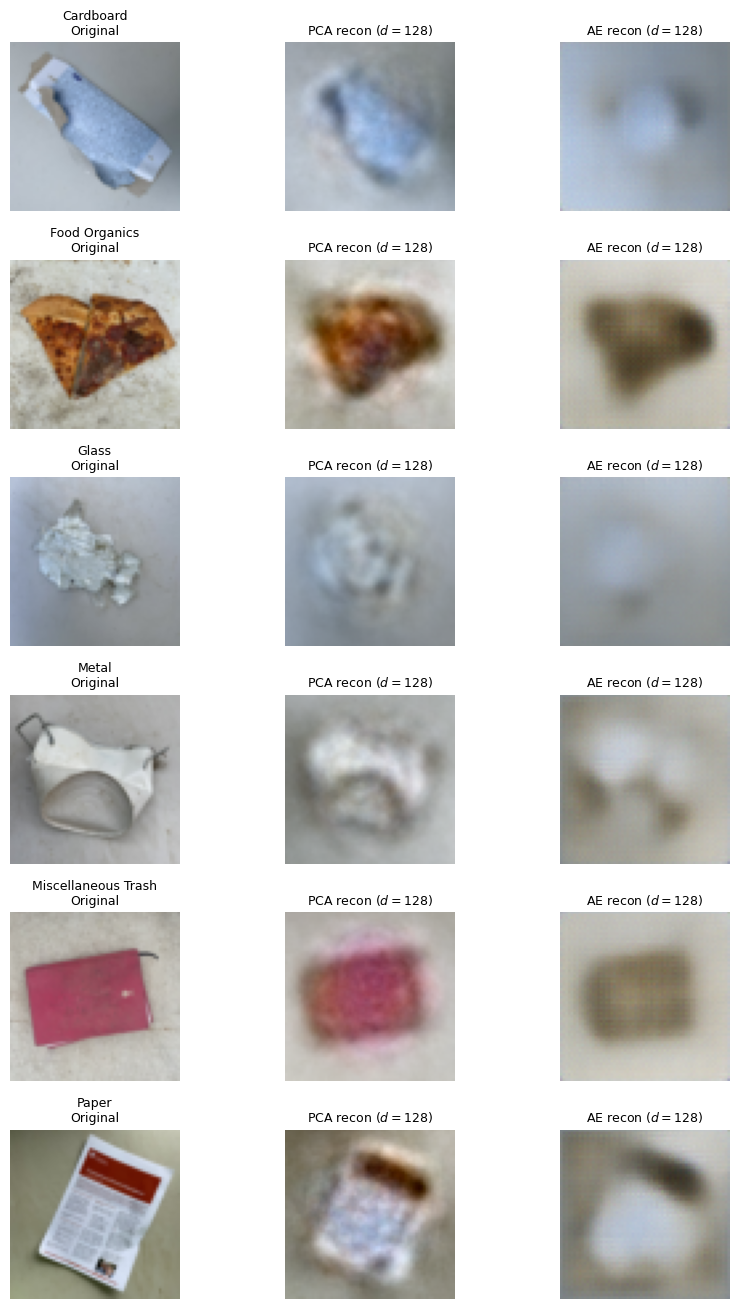

Saved: figures/reconstruction_examples.pdf


In [26]:
# --- Export reconstruction examples (RealWaste) as PDF for the report ---
os.makedirs("figures", exist_ok=True)

# Sanity checks: required variables must exist
required = ["Xrw_te", "yrw_te", "Xte_pca", "Xte_ae_img", "rw_base_ds", "d_rw"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}. Run PCA recon + AE recon sections first.")

class_names = rw_base_ds.classes

# Labels to numpy
y_np = yrw_te.detach().cpu().numpy() if hasattr(yrw_te, "detach") else np.asarray(yrw_te)

# Helper: convert (C,H,W) -> (H,W,C) in [0,1]
def to_img_np(x):
    if hasattr(x, "detach"):  # torch tensor
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    x = np.clip(x, 0, 1)
    return np.transpose(x, (1, 2, 0))

# Pick diverse examples (up to max_rows), preferring different classes
max_rows = 6  # set to 9 if you want one per class (bigger figure)
indices = []
for c in range(len(class_names)):
    idx_c = np.where(y_np == c)[0]
    if len(idx_c) > 0:
        indices.append(int(idx_c[0]))
    if len(indices) >= max_rows:
        break

# Fallback: if needed, fill with the first samples
i = 0
while len(indices) < max_rows and i < len(y_np):
    if i not in indices:
        indices.append(i)
    i += 1

nrows = len(indices)
ncols = 3  # Original | PCA recon | AE recon

plt.figure(figsize=(ncols * 3.0, nrows * 2.2))

for r, idx in enumerate(indices):
    y = int(y_np[idx])
    cls = class_names[y] if y < len(class_names) else f"class {y}"

    # Original
    ax = plt.subplot(nrows, ncols, r * ncols + 1)
    ax.imshow(to_img_np(Xrw_te[idx]))
    ax.set_title(f"{cls}\nOriginal", fontsize=9)
    ax.axis("off")

    # PCA reconstruction
    ax = plt.subplot(nrows, ncols, r * ncols + 2)
    ax.imshow(to_img_np(Xte_pca[idx]))
    ax.set_title(f"PCA recon ($d={d_rw}$)", fontsize=9)
    ax.axis("off")

    # AE reconstruction
    ax = plt.subplot(nrows, ncols, r * ncols + 3)
    ax.imshow(to_img_np(Xte_ae_img[idx]))
    ax.set_title(f"AE recon ($d={d_rw}$)", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("figures/reconstruction_examples.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/reconstruction_examples.pdf")


In [27]:
# Batch size used for CNN classification experiments
bs = 64

# -----------------------------
# DataLoaders for CNN on PCA-reconstructed images
# Here Xtr_pca/Xva_pca/Xte_pca are NumPy arrays produced by inverse PCA, with shape (N, 3, IMG_DR, IMG_DR) and values clipped to [0,1]
# We convert them to float32 torch tensors and pair them with the original labels
# -----------------------------
train_loader_pca = DataLoader(
    TensorDataset(torch.tensor(Xtr_pca, dtype=torch.float32), yrw_tr),
    batch_size=bs,
    shuffle=True   # shuffle for better SGD training
)
val_loader_pca = DataLoader(
    TensorDataset(torch.tensor(Xva_pca, dtype=torch.float32), yrw_va),
    batch_size=bs,
    shuffle=False  # deterministic evaluation
)
test_loader_pca = DataLoader(
    TensorDataset(torch.tensor(Xte_pca, dtype=torch.float32), yrw_te),
    batch_size=bs,
    shuffle=False
)

# -----------------------------
# DataLoaders for CNN on AE-reconstructed images
# Xtr_ae_img/Xva_ae_img/Xte_ae_img are torch tensors returned by the ConvAE reconstruct() helper,
# already with shape (N, 3, IMG_DR, IMG_DR) and (thanks to Sigmoid) values in [0,1]
# We wrap them directly into TensorDataset with the same labels
# -----------------------------
train_loader_ae = DataLoader(
    TensorDataset(Xtr_ae_img, yrw_tr),
    batch_size=bs,
    shuffle=True
)
val_loader_ae = DataLoader(
    TensorDataset(Xva_ae_img, yrw_va),
    batch_size=bs,
    shuffle=False
)
test_loader_ae = DataLoader(
    TensorDataset(Xte_ae_img, yrw_te),
    batch_size=bs,
    shuffle=False
)

In [28]:
# Collect results for a final comparison table
# CNN hyper-parameter selection via Stratified K-Fold CV (on TRAIN only),
# then final training with early-stopping on VAL, and evaluation on TEST

# -----------------------------
# Reproducibility helper
# -----------------------------
def set_all_seeds(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds(SEED)

# -----------------------------
# Basic helpers
# -----------------------------
def accuracy_from_loader(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct / max(total, 1)

def train_cnn_with_history(
    train_loader, val_loader,
    n_classes: int,
    max_epochs: int = 30,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    patience: int = 5
):
    model = SmallCNN(n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    best_val = float("inf")
    best_state = None
    bad = 0

    hist_train, hist_val = [], []
    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        # ---- train ----
        model.train()
        tr_sum, n_tr = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            tr_sum += loss.item() * xb.size(0)
            n_tr += xb.size(0)
        tr_loss = tr_sum / max(n_tr, 1)

        # ---- val ----
        model.eval()
        va_sum, n_va = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                va_sum += loss_fn(logits, yb).item() * xb.size(0)
                n_va += xb.size(0)
        va_loss = va_sum / max(n_va, 1)

        hist_train.append(tr_loss)
        hist_val.append(va_loss)

        # ---- early stopping ----
        if va_loss < best_val - 1e-8:
            best_val = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    elapsed = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, np.array(hist_train), np.array(hist_val), float(elapsed)

# -----------------------------
# Hyper-parameter selection with Stratified K-Fold CV (TRAIN only)
# We tune only optimizer-related HPs (lr, weight_decay) to keep CV feasible.
# -----------------------------
def select_cnn_hparams_cv(
    Xtr_tensor, ytr_tensor,
    n_classes: int,
    param_grid,
    n_splits: int = 3,
    bs: int = 64,
    max_epochs_cv: int = 8,
    patience_cv: int = 2
):
    y_np = ytr_tensor.detach().cpu().numpy()
    ds = TensorDataset(Xtr_tensor, ytr_tensor)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    rows = []
    for params in param_grid:
        accs = []
        for fold, (idx_tr, idx_va) in enumerate(skf.split(np.zeros_like(y_np), y_np), 1):
            set_all_seeds(SEED + fold)

            tr_loader = DataLoader(Subset(ds, idx_tr), batch_size=bs, shuffle=True)
            va_loader = DataLoader(Subset(ds, idx_va), batch_size=bs, shuffle=False)

            model, _, _, _ = train_cnn_with_history(
                tr_loader, va_loader,
                n_classes=n_classes,
                max_epochs=max_epochs_cv,
                lr=params["lr"],
                weight_decay=params["weight_decay"],
                patience=patience_cv
            )
            acc = accuracy_from_loader(model, va_loader)
            accs.append(acc)

        rows.append({
            **params,
            "cv_acc_mean": float(np.mean(accs)),
            "cv_acc_std": float(np.std(accs)),
        })

    cv_df = pd.DataFrame(rows).sort_values("cv_acc_mean", ascending=False).reset_index(drop=True)
    best_params = cv_df.iloc[0][["lr", "weight_decay"]].to_dict()
    return best_params, cv_df

# -----------------------------
# Setup
# -----------------------------
rows = []
class_names = rw_base_ds.classes
n_classes = len(class_names)
bs = 64

# Param grid (small)
param_grid_cnn = [
    {"lr": 1e-3, "weight_decay": 0.0},
    {"lr": 1e-3, "weight_decay": 1e-4},
    {"lr": 5e-4, "weight_decay": 0.0},
    {"lr": 5e-4, "weight_decay": 1e-4},
]

# -----------------------------
# CV on TRAIN (ORIGINAL 64x64) to pick HPs
# -----------------------------
print("\n[RealWaste CNN] Hyper-parameter selection (Stratified 3-Fold CV) — ORIGINAL 64x64")
best_hp_cnn, cv_cnn = select_cnn_hparams_cv(
    Xrw_tr, yrw_tr,
    n_classes=n_classes,
    param_grid=param_grid_cnn,
    n_splits=3,
    bs=bs,
    max_epochs_cv=8,
    patience_cv=2
)
display(cv_cnn)
print("Best HP (CNN):", best_hp_cnn)

# -----------------------------
# Train FINAL models (early-stop on VAL) + evaluate on TEST
# -----------------------------
print("\n=== TRAIN FINAL on ORIGINAL 64 ===")
m_orig, tr_cnn_orig, va_cnn_orig, t_cnn_orig = train_cnn_with_history(
    train_loader_orig64, val_loader_orig64,
    n_classes=n_classes,
    max_epochs=30,
    lr=best_hp_cnn["lr"],
    weight_decay=best_hp_cnn["weight_decay"],
    patience=5
)
acc, f1m, cm = eval_cnn(m_orig, test_loader_orig64)
rows.append({"repr": "original", "acc": acc, "f1_macro": f1m})
print("TEST original:", acc, f1m)

print("\n=== TRAIN FINAL on PCA recon (d=128) ===")
m_pca, tr_cnn_pca, va_cnn_pca, t_cnn_pca = train_cnn_with_history(
    train_loader_pca, val_loader_pca,
    n_classes=n_classes,
    max_epochs=30,
    lr=best_hp_cnn["lr"],
    weight_decay=best_hp_cnn["weight_decay"],
    patience=5
)
acc, f1m, cm = eval_cnn(m_pca, test_loader_pca)
rows.append({"repr": "pca_recon", "acc": acc, "f1_macro": f1m})
print("TEST pca:", acc, f1m)

print("\n=== TRAIN FINAL on AE recon (d=128) ===")
m_ae, tr_cnn_ae, va_cnn_ae, t_cnn_ae = train_cnn_with_history(
    train_loader_ae, val_loader_ae,
    n_classes=n_classes,
    max_epochs=30,
    lr=best_hp_cnn["lr"],
    weight_decay=best_hp_cnn["weight_decay"],
    patience=5
)
acc, f1m, cm = eval_cnn(m_ae, test_loader_ae)
rows.append({"repr": "ae_recon", "acc": acc, "f1_macro": f1m})
print("TEST ae:", acc, f1m)

# -----------------------------
# Results table
# -----------------------------
results_rw = pd.DataFrame(rows).sort_values("acc", ascending=False).reset_index(drop=True)
print("\nRealWaste CNN — TEST comparison (final models)")
display(results_rw)

# Save chosen HP for report
best_hp_cnn_selected = best_hp_cnn
print("\nSelected hyper-parameters (CNN RealWaste):")
print(best_hp_cnn_selected)



[RealWaste CNN] Hyper-parameter selection (Stratified 3-Fold CV) — ORIGINAL 64x64


,lr,weight_decay,cv_acc_mean,cv_acc_std
0,0.0010,0.0000,0.590492,0.023827
1,0.0010,0.0001,0.564937,0.026467
2,0.0005,0.0000,0.535476,0.008110
3,0.0005,0.0001,0.525255,0.000627


Best HP (CNN): {'lr': 0.001, 'weight_decay': 0.0}

=== TRAIN FINAL on ORIGINAL 64 ===
TEST original: 0.6802244039270687 0.6785834790603891

=== TRAIN FINAL on PCA recon (d=128) ===
TEST pca: 0.6479663394109397 0.6430807019738285

=== TRAIN FINAL on AE recon (d=128) ===
TEST ae: 0.5399719495091164 0.5194454709845536

RealWaste CNN — TEST comparison (final models)


,repr,acc,f1_macro
0,original,0.680224,0.678583
1,pca_recon,0.647966,0.643081
2,ae_recon,0.539972,0.519445



Selected hyper-parameters (CNN RealWaste):
{'lr': 0.001, 'weight_decay': 0.0}


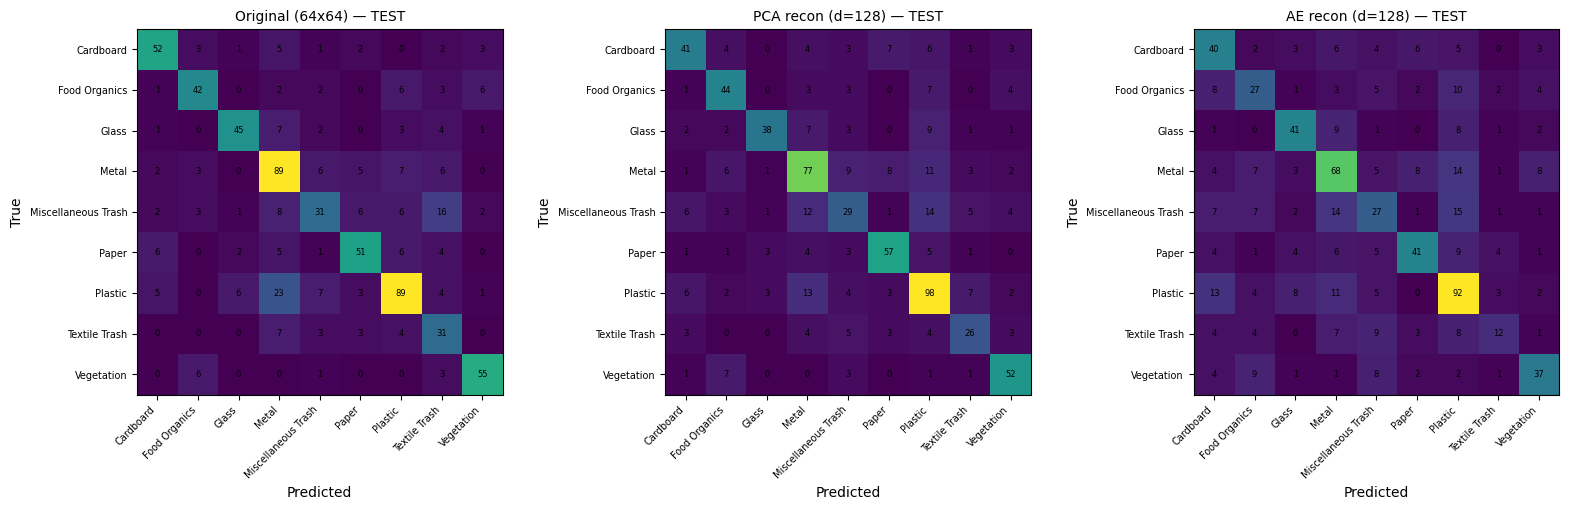

Saved: figures/confusion_matrices.pdf


In [29]:
# --- Export: Confusion matrices (RealWaste TEST) as a single PDF for the report ---
os.makedirs("figures", exist_ok=True)

required = ["m_orig", "m_pca", "m_ae", "test_loader_orig64", "test_loader_pca", "test_loader_ae", "rw_base_ds"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}. Run the RealWaste CNN training section first.")

class_names = rw_base_ds.classes

def preds_from_loader(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1).detach().cpu().numpy()
            y_pred.append(pred)
            y_true.append(yb.detach().cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)

def plot_cm(ax, cm, labels, title):
    im = ax.imshow(cm)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)

    # Write counts in cells (small font)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=6)

# Compute CMs
y_t, y_p = preds_from_loader(m_orig, test_loader_orig64)
cm_orig = confusion_matrix(y_t, y_p, labels=np.arange(len(class_names)))

y_t, y_p = preds_from_loader(m_pca, test_loader_pca)
cm_pca = confusion_matrix(y_t, y_p, labels=np.arange(len(class_names)))

y_t, y_p = preds_from_loader(m_ae, test_loader_ae)
cm_ae = confusion_matrix(y_t, y_p, labels=np.arange(len(class_names)))

# Plot as a row of 3 matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_cm(axes[0], cm_orig, class_names, "Original (64x64) — TEST")
plot_cm(axes[1], cm_pca,  class_names, "PCA recon (d=128) — TEST")
plot_cm(axes[2], cm_ae,   class_names, "AE recon (d=128) — TEST")

plt.tight_layout()
plt.savefig("figures/confusion_matrices.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/confusion_matrices.pdf")


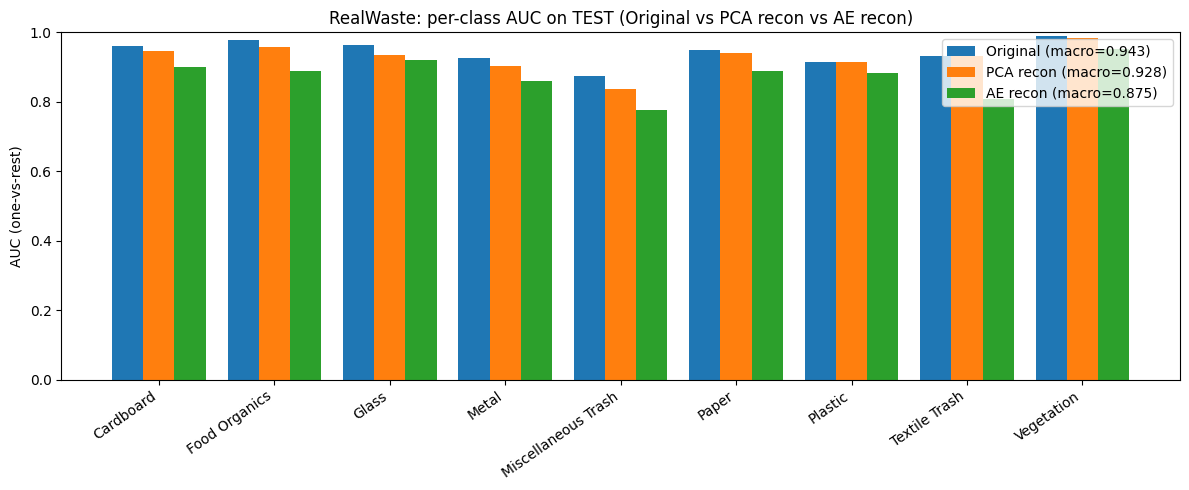

Saved: figures/roc_curves_multiclass.pdf
Per-class AUCs:
-    Cardboard | orig=0.960  pca=0.947  ae=0.899
- Food Organics | orig=0.977  pca=0.958  ae=0.890
-        Glass | orig=0.962  pca=0.936  ae=0.921
-        Metal | orig=0.926  pca=0.902  ae=0.859
- Miscellaneous Trash | orig=0.874  pca=0.836  ae=0.776
-        Paper | orig=0.950  pca=0.941  ae=0.887
-      Plastic | orig=0.916  pca=0.916  ae=0.884
- Textile Trash | orig=0.932  pca=0.933  ae=0.809
-   Vegetation | orig=0.988  pca=0.983  ae=0.952


In [30]:
# --- Export: Per-class AUC bar chart (OVR) for RealWaste (TEST) ---
os.makedirs("figures", exist_ok=True)

required = ["m_orig", "m_pca", "m_ae",
            "test_loader_orig64", "test_loader_pca", "test_loader_ae",
            "rw_base_ds"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}. Run the RealWaste CNN training section first.")

class_names = rw_base_ds.classes
n_classes = len(class_names)

def probs_and_labels(model, loader):
    model.eval()
    probs_list, y_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            probs_list.append(probs)
            y_list.append(yb.detach().cpu().numpy())
    return np.vstack(probs_list), np.concatenate(y_list)

# Get probabilities on TEST
probs_o, y_o = probs_and_labels(m_orig, test_loader_orig64)
probs_p, y_p = probs_and_labels(m_pca,  test_loader_pca)
probs_a, y_a = probs_and_labels(m_ae,   test_loader_ae)

# Binarize labels for one-vs-rest AUC
Y_o = label_binarize(y_o, classes=np.arange(n_classes))
Y_p = label_binarize(y_p, classes=np.arange(n_classes))
Y_a = label_binarize(y_a, classes=np.arange(n_classes))

# Per-class AUC (OVR); average=None returns one AUC per class
auc_o = roc_auc_score(Y_o, probs_o, average=None)
auc_p = roc_auc_score(Y_p, probs_p, average=None)
auc_a = roc_auc_score(Y_a, probs_a, average=None)

# Macro AUCs (mean of per-class AUCs)
macro_o = float(np.mean(auc_o))
macro_p = float(np.mean(auc_p))
macro_a = float(np.mean(auc_a))

# ---- Plot grouped bars ----
x = np.arange(n_classes)
w = 0.27

plt.figure(figsize=(12, 5))
plt.bar(x - w, auc_o, width=w, label=f"Original (macro={macro_o:.3f})")
plt.bar(x,      auc_p, width=w, label=f"PCA recon (macro={macro_p:.3f})")
plt.bar(x + w,  auc_a, width=w, label=f"AE recon (macro={macro_a:.3f})")

plt.xticks(x, class_names, rotation=35, ha="right")
plt.ylim(0.0, 1.0)
plt.ylabel("AUC (one-vs-rest)")
plt.title("RealWaste: per-class AUC on TEST (Original vs PCA recon vs AE recon)")
plt.legend()
plt.tight_layout()

# Save using the same filename used in the LaTeX report
plt.savefig("figures/roc_curves_multiclass.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/roc_curves_multiclass.pdf")
print("Per-class AUCs:")
for i, name in enumerate(class_names):
    print(f"- {name:>12s} | orig={auc_o[i]:.3f}  pca={auc_p[i]:.3f}  ae={auc_a[i]:.3f}")


In [31]:
# -----------------------------
# Confusion matrix + classification report utilities
# -----------------------------

# Collect true labels and predicted labels from a model over a given DataLoader
# We run the model in eval mode and disable gradients for efficiency
def get_preds(model, loader):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for xb, yb in loader:
            # Move the batch to the same device as the model (CPU/GPU)
            xb = xb.to(device)

            # Forward pass: model outputs logits (unnormalized scores) of shape (B, n_classes)
            logits = model(xb).cpu()  # move to CPU for argmax / numpy conversion

            # Predicted class = index of the maximum logit for each sample
            pred = torch.argmax(logits, dim=1)

            # Store ground truth and predictions for this batch
            ys.append(yb)
            preds.append(pred)

    # Concatenate all batches into single vectors and convert to NumPy arrays
    y_true = torch.cat(ys).numpy()
    y_pred = torch.cat(preds).numpy()
    return y_true, y_pred


# Pretty-print confusion matrix and a per-class classification report
# - Confusion matrix: how predictions distribute across true classes
# - Classification report: precision/recall/F1 per class + macro/weighted averages
def pretty_cm_and_report(model, loader, class_names, title=""):
    # Get true/pred labels
    y_true, y_pred = get_preds(model, loader)

    # Compute confusion matrix (rows=true classes, cols=predicted classes)
    cm = confusion_matrix(y_true, y_pred)

    # Wrap in a DataFrame with class names for readability
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    # Print header and display matrix
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)
    display(cm_df)

    # Print detailed per-class metrics
    # digits=3 formats numbers; zero_division=0 avoids warnings if a class has no predicted samples
    print("\nClassification report (per class):")
    rep = classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=3,
        zero_division=0
    )
    print(rep)


# Class names
class_names = rw_base_ds.classes

# Compute confusion matrix + report for each of the three CNNs (original / PCA recon / AE recon)
pretty_cm_and_report(m_orig, test_loader_orig64, class_names, title="ORIGINAL 64x64 - TEST")
pretty_cm_and_report(m_pca,  test_loader_pca,    class_names, title="PCA recon (d=128) - TEST")
pretty_cm_and_report(m_ae,   test_loader_ae,     class_names, title="AE recon (d=128) - TEST")



ORIGINAL 64x64 - TEST


,Cardboard,Food Organics,Glass,Metal,Miscellaneous Trash,Paper,Plastic,Textile Trash,Vegetation
Cardboard,52,3,1,5,1,2,0,2,3
Food Organics,1,42,0,2,2,0,6,3,6
Glass,1,0,45,7,2,0,3,4,1
Metal,2,3,0,89,6,5,7,6,0
Miscellaneous Trash,2,3,1,8,31,6,6,16,2
Paper,6,0,2,5,1,51,6,4,0
Plastic,5,0,6,23,7,3,89,4,1
Textile Trash,0,0,0,7,3,3,4,31,0
Vegetation,0,6,0,0,1,0,0,3,55



Classification report (per class):
                     precision    recall  f1-score   support

          Cardboard      0.754     0.754     0.754        69
      Food Organics      0.737     0.677     0.706        62
              Glass      0.818     0.714     0.763        63
              Metal      0.610     0.754     0.674       118
Miscellaneous Trash      0.574     0.413     0.481        75
              Paper      0.729     0.680     0.703        75
            Plastic      0.736     0.645     0.687       138
      Textile Trash      0.425     0.646     0.512        48
         Vegetation      0.809     0.846     0.827        65

           accuracy                          0.680       713
          macro avg      0.688     0.681     0.679       713
       weighted avg      0.692     0.680     0.681       713


PCA recon (d=128) - TEST


,Cardboard,Food Organics,Glass,Metal,Miscellaneous Trash,Paper,Plastic,Textile Trash,Vegetation
Cardboard,41,4,0,4,3,7,6,1,3
Food Organics,1,44,0,3,3,0,7,0,4
Glass,2,2,38,7,3,0,9,1,1
Metal,1,6,1,77,9,8,11,3,2
Miscellaneous Trash,6,3,1,12,29,1,14,5,4
Paper,1,1,3,4,3,57,5,1,0
Plastic,6,2,3,13,4,3,98,7,2
Textile Trash,3,0,0,4,5,3,4,26,3
Vegetation,1,7,0,0,3,0,1,1,52



Classification report (per class):
                     precision    recall  f1-score   support

          Cardboard      0.661     0.594     0.626        69
      Food Organics      0.638     0.710     0.672        62
              Glass      0.826     0.603     0.697        63
              Metal      0.621     0.653     0.636       118
Miscellaneous Trash      0.468     0.387     0.423        75
              Paper      0.722     0.760     0.740        75
            Plastic      0.632     0.710     0.669       138
      Textile Trash      0.578     0.542     0.559        48
         Vegetation      0.732     0.800     0.765        65

           accuracy                          0.648       713
          macro avg      0.653     0.640     0.643       713
       weighted avg      0.648     0.648     0.645       713


AE recon (d=128) - TEST


,Cardboard,Food Organics,Glass,Metal,Miscellaneous Trash,Paper,Plastic,Textile Trash,Vegetation
Cardboard,40,2,3,6,4,6,5,0,3
Food Organics,8,27,1,3,5,2,10,2,4
Glass,1,0,41,9,1,0,8,1,2
Metal,4,7,3,68,5,8,14,1,8
Miscellaneous Trash,7,7,2,14,27,1,15,1,1
Paper,4,1,4,6,5,41,9,4,1
Plastic,13,4,8,11,5,0,92,3,2
Textile Trash,4,4,0,7,9,3,8,12,1
Vegetation,4,9,1,1,8,2,2,1,37



Classification report (per class):
                     precision    recall  f1-score   support

          Cardboard      0.471     0.580     0.519        69
      Food Organics      0.443     0.435     0.439        62
              Glass      0.651     0.651     0.651        63
              Metal      0.544     0.576     0.560       118
Miscellaneous Trash      0.391     0.360     0.375        75
              Paper      0.651     0.547     0.594        75
            Plastic      0.564     0.667     0.611       138
      Textile Trash      0.480     0.250     0.329        48
         Vegetation      0.627     0.569     0.597        65

           accuracy                          0.540       713
          macro avg      0.536     0.515     0.519       713
       weighted avg      0.540     0.540     0.535       713




ROC/AUC - ORIGINAL 64x64 (TEST)
AUC macro (OVR):    0.9428
AUC weighted (OVR): 0.9382
AUC micro:          0.9463


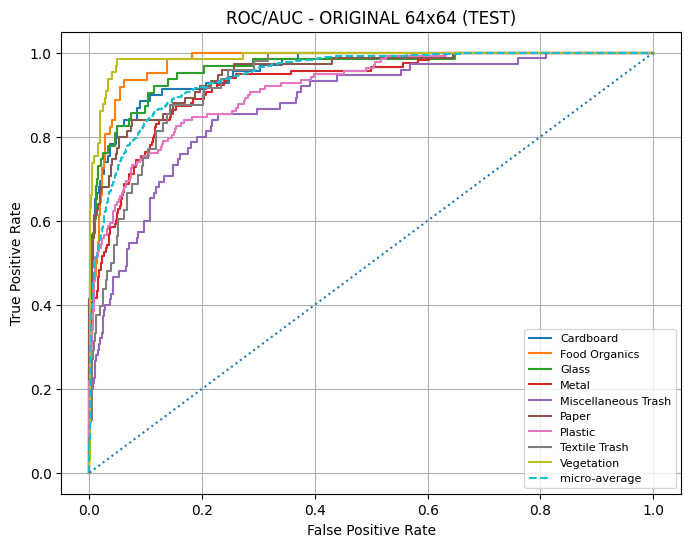


ROC/AUC - PCA recon d=128 (TEST)
AUC macro (OVR):    0.9280
AUC weighted (OVR): 0.9236
AUC micro:          0.9325


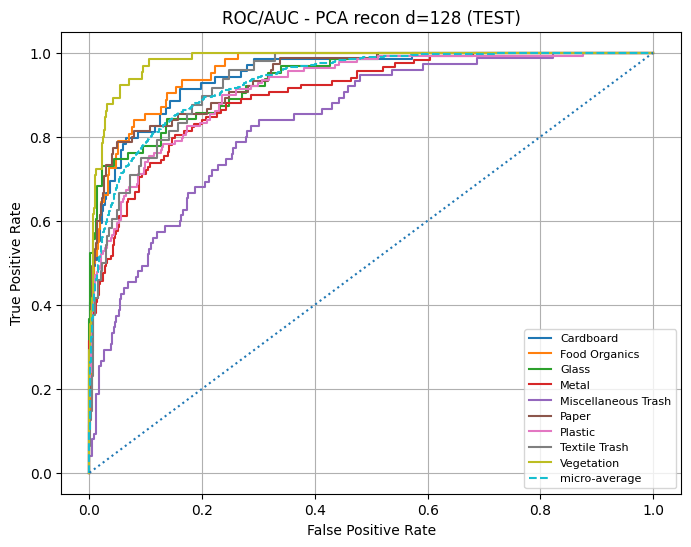


ROC/AUC - AE recon d=128 (TEST)
AUC macro (OVR):    0.8751
AUC weighted (OVR): 0.8751
AUC micro:          0.8867


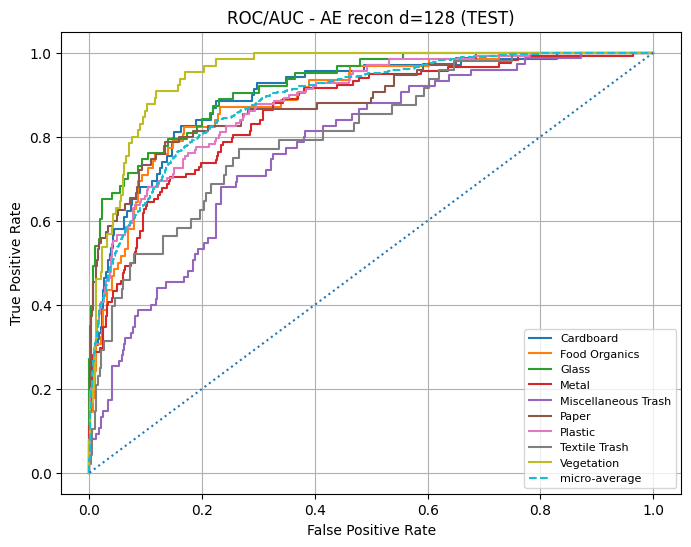

In [32]:
# ROC/AUC (multiclass OVR) — TEST

# Ensure class names and number of classes are available
if "class_names" not in globals():
    class_names = rw_base_ds.classes
if "n_classes" not in globals():
    n_classes = len(class_names)

def eval_roc_auc_clean(model, loader, title, class_names):
    # Get true labels and per-class scores/probabilities
    y_true, y_score = predict_proba_cnn(model, loader)

    # Compute macro/weighted (OVR) and micro ROC-AUC
    auc_macro, auc_weighted, auc_micro = roc_auc_multiclass(
        y_true, y_score, n_classes=len(class_names)
    )

    # Print AUC summary
    print(f"\n{title}")
    print(f"AUC macro (OVR):    {auc_macro:.4f}")
    print(f"AUC weighted (OVR): {auc_weighted:.4f}")
    print(f"AUC micro:          {auc_micro:.4f}")

    # Plot per-class ROC curves (OVR)
    plot_roc_curves(y_true, y_score, class_names, title=title)

# Evaluate ROC/AUC on the test set for each representation
eval_roc_auc_clean(m_orig, test_loader_orig64, "ROC/AUC - ORIGINAL 64x64 (TEST)", class_names)
eval_roc_auc_clean(m_pca,  test_loader_pca,    "ROC/AUC - PCA recon d=128 (TEST)", class_names)
eval_roc_auc_clean(m_ae,   test_loader_ae,     "ROC/AUC - AE recon d=128 (TEST)", class_names)


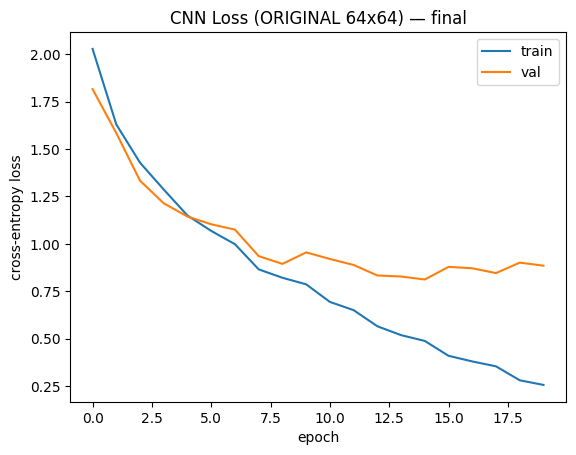

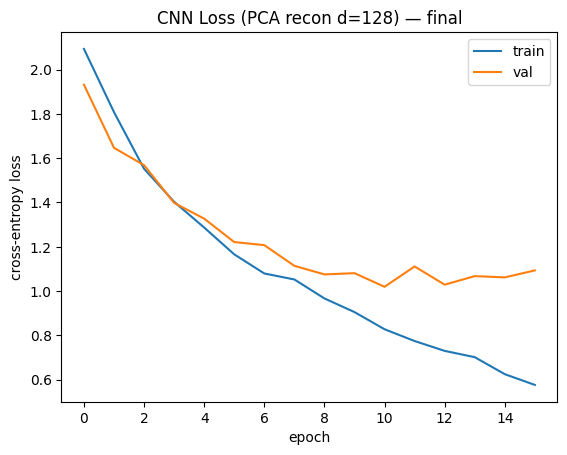

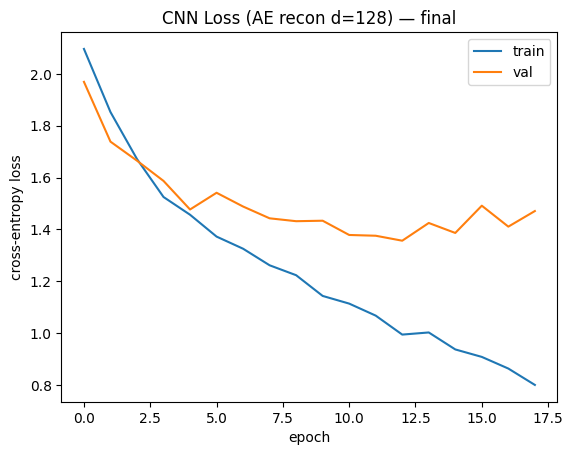

Training time (s): original = 11.92 | pca = 9.52 | ae = 10.64


In [33]:
# CNN loss curves + training times (RealWaste)
# Uses histories/times produced by the FINAL training cell

def plot_history(tr, va, title):
    tr = np.asarray(tr, dtype=float)
    va = np.asarray(va, dtype=float)
    plt.figure()
    plt.plot(tr, label="train")
    plt.plot(va, label="val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("cross-entropy loss")
    plt.legend()
    plt.show()

# Plot curves from the FINAL runs
plot_history(tr_cnn_orig, va_cnn_orig, "CNN Loss (ORIGINAL 64x64) — final")
plot_history(tr_cnn_pca,  va_cnn_pca,  "CNN Loss (PCA recon d=128) — final")
plot_history(tr_cnn_ae,   va_cnn_ae,   "CNN Loss (AE recon d=128) — final")

# Print training time comparison (FINAL)
print(
    "Training time (s): original =", round(t_cnn_orig, 2),
    "| pca =", round(t_cnn_pca, 2),
    "| ae =", round(t_cnn_ae, 2)
)


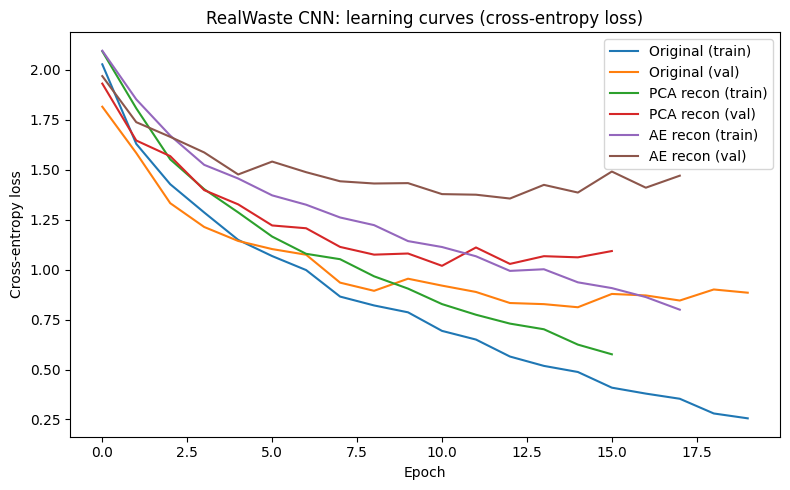

Saved: figures/cnn_learning_curves.pdf


In [34]:
# --- Export: RealWaste CNN learning curves (train vs val CE loss) as PDF for the report ---
os.makedirs("figures", exist_ok=True)

required = [
    "tr_cnn_orig", "va_cnn_orig",
    "tr_cnn_pca",  "va_cnn_pca",
    "tr_cnn_ae",   "va_cnn_ae",
]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing variables: {missing}. Run the RealWaste CNN training cell first.")

def _to_np(x):
    return np.asarray(x, dtype=float)

tr_o, va_o = _to_np(tr_cnn_orig), _to_np(va_cnn_orig)
tr_p, va_p = _to_np(tr_cnn_pca),  _to_np(va_cnn_pca)
tr_a, va_a = _to_np(tr_cnn_ae),   _to_np(va_cnn_ae)

plt.figure(figsize=(8, 5))

plt.plot(tr_o, label="Original (train)")
plt.plot(va_o, label="Original (val)")

plt.plot(tr_p, label="PCA recon (train)")
plt.plot(va_p, label="PCA recon (val)")

plt.plot(tr_a, label="AE recon (train)")
plt.plot(va_a, label="AE recon (val)")

plt.title("RealWaste CNN: learning curves (cross-entropy loss)")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.tight_layout()

plt.savefig("figures/cnn_learning_curves.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/cnn_learning_curves.pdf")

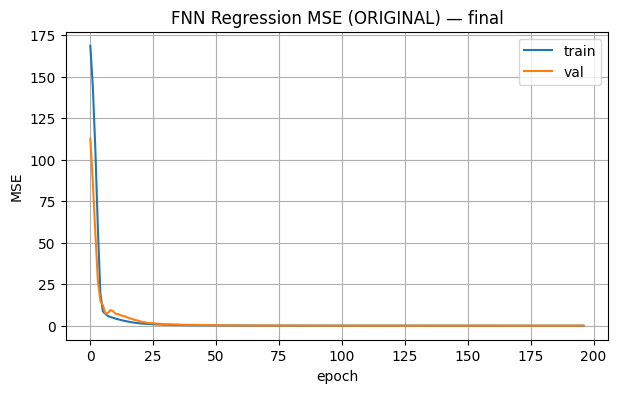

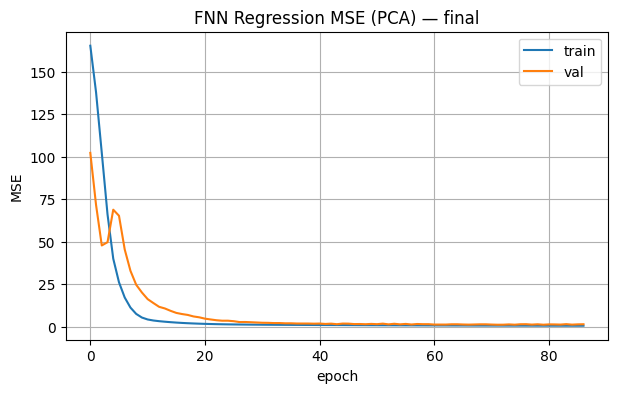

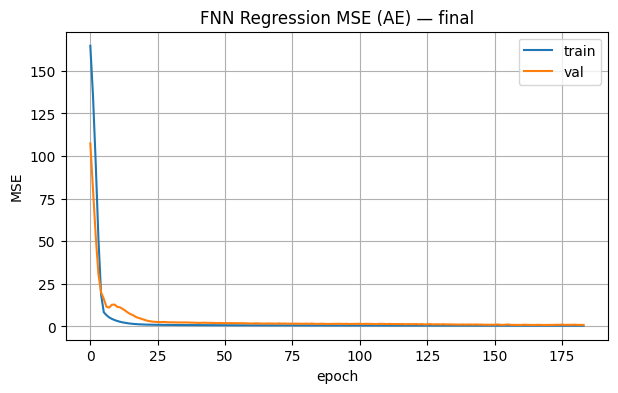

Training time (s): original = 13.37 | pca = 5.59 | ae = 12.62


In [35]:
# FNN loss curves + training times (AirQuality)
# Uses histories/times produced by the FINAL training cell

# Plot train vs validation MSE curves for each representation (FINAL runs)
plot_curve(tr_fnn_orig, va_fnn_orig, "FNN Regression MSE (ORIGINAL) — final", ylab="MSE")
plot_curve(tr_fnn_pca,  va_fnn_pca,  "FNN Regression MSE (PCA) — final",      ylab="MSE")
plot_curve(tr_fnn_ae,   va_fnn_ae,   "FNN Regression MSE (AE) — final",       ylab="MSE")

# Print training time comparison across the three FINAL runs
print("Training time (s): original =", round(t_fnn_orig, 2),
      "| pca =", round(t_fnn_pca, 2),
      "| ae =", round(t_fnn_ae, 2))


In [36]:
# Training-time summary table

# Build a DataFrame collecting training times for each task (CNN/FNN) and representation (original/PCA/AE)
times = pd.DataFrame([
    {"task": "CNN RealWaste",  "repr": "original", "train_time_s": t_cnn_orig},
    {"task": "CNN RealWaste",  "repr": "pca",      "train_time_s": t_cnn_pca},
    {"task": "CNN RealWaste",  "repr": "ae",       "train_time_s": t_cnn_ae},
    {"task": "FNN AirQuality", "repr": "original", "train_time_s": t_fnn_orig},
    {"task": "FNN AirQuality", "repr": "pca",      "train_time_s": t_fnn_pca},
    {"task": "FNN AirQuality", "repr": "ae",       "train_time_s": t_fnn_ae},
])

# Display the timing table
times


,task,repr,train_time_s
0,CNN RealWaste,original,11.917951
1,CNN RealWaste,pca,9.515938
2,CNN RealWaste,ae,10.638588
3,FNN AirQuality,original,13.370146
4,FNN AirQuality,pca,5.587609
5,FNN AirQuality,ae,12.622535


In [37]:
# =========================================================
# FINAL SUMMARY — tables used in the report (NO recomputation)
# =========================================================
# This cell does NOT retrain models. It only summarizes objects already computed:
# - df_kmeans_metrics for Paddy K-Means (TEST)
# - results_aq (or results_aq_rounded) for AirQuality FNN (TEST)
# - results_rw for RealWaste CNN (TEST)

import pandas as pd

# -------------------------
# 1) Paddy (KMeans) — final eval on TEST
# -------------------------
if "df_kmeans_metrics" not in globals():
    raise NameError("df_kmeans_metrics not found. Run the KMeans (Paddy) section first.")

kmeans_summary = df_kmeans_metrics.copy()
kmeans_summary["repr"] = kmeans_summary["repr"].astype(str).str.lower().replace({
    "orig": "original",
    "pca": "pca",
    "ae": "ae"
})

kmeans_summary = kmeans_summary[["repr", "k", "silhouette_test", "objective_test"]] \
    .sort_values("silhouette_test", ascending=False) \
    .reset_index(drop=True)

print("\n=== Paddy (KMeans) — TEST ===")
display(kmeans_summary)

# -------------------------
# 2) AirQuality (FNN) — final eval on TEST
# -------------------------
if "results_aq" in globals():
    aq_summary = results_aq.copy()
elif "results_aq_rounded" in globals():
    aq_summary = results_aq_rounded.copy()
else:
    raise NameError("results_aq/results_aq_rounded not found. Run the AirQuality FNN section first.")

aq_summary["repr"] = aq_summary["repr"].astype(str).str.lower().replace({"orig": "original"})
aq_summary = aq_summary[["repr", "RMSE", "MAE", "R2", "train_time_s"]] \
    .sort_values("RMSE") \
    .reset_index(drop=True)

print("\n=== AirQuality (FNN Regression) — TEST ===")
display(aq_summary)

# -------------------------
# 3) RealWaste (CNN) — final eval on TEST
# -------------------------
if "results_rw" not in globals():
    raise NameError("results_rw not found. Run the RealWaste CNN section first.")

rw_summary = results_rw.copy()
rw_summary["repr"] = rw_summary["repr"].astype(str).str.lower()

# keep names exactly as used in the report
rw_summary["repr"] = rw_summary["repr"].replace({
    "orig": "original",
    "pca": "pca_recon",
    "ae": "ae_recon"
})

rw_summary = rw_summary[["repr", "acc", "f1_macro"]]

print("\n=== RealWaste (CNN Classification) — TEST ===")
display(rw_summary)

# -------------------------
# 4) At-a-glance (one key metric per task)
# -------------------------
at_a_glance = []

for _, r in kmeans_summary.iterrows():
    at_a_glance.append({
        "task": "Paddy (KMeans)",
        "repr": r["repr"],
        "key_metric": "sil_test",
        "value": float(r["silhouette_test"])
    })

for _, r in aq_summary.iterrows():
    at_a_glance.append({
        "task": "AirQuality (FNN)",
        "repr": r["repr"],
        "key_metric": "RMSE",
        "value": float(r["RMSE"])
    })

for _, r in rw_summary.iterrows():
    at_a_glance.append({
        "task": "RealWaste (CNN)",
        "repr": r["repr"],
        "key_metric": "acc",
        "value": float(r["acc"])
    })

at_a_glance = pd.DataFrame(at_a_glance)

print("\n=== At-a-glance ===")
display(at_a_glance.sort_values(["task", "repr"]).reset_index(drop=True))



=== Paddy (KMeans) — TEST ===


,repr,k,silhouette_test,objective_test
0,ae,6,0.558438,1248.635620
1,pca,12,0.533009,1549.173073
2,original,12,0.532722,1551.405317



=== AirQuality (FNN Regression) — TEST ===


,repr,RMSE,MAE,R2,train_time_s
0,original,0.313805,0.237668,0.997329,13.370146
1,pca,1.799423,1.647259,0.912175,5.587609
2,ae,1.859391,1.589847,0.906223,12.622535



=== RealWaste (CNN Classification) — TEST ===


,repr,acc,f1_macro
0,original,0.680224,0.678583
1,pca_recon,0.647966,0.643081
2,ae_recon,0.539972,0.519445



=== At-a-glance ===


,task,repr,key_metric,value
0,AirQuality (FNN),ae,RMSE,1.859391
1,AirQuality (FNN),original,RMSE,0.313805
2,AirQuality (FNN),pca,RMSE,1.799423
3,Paddy (KMeans),ae,sil_test,0.558438
4,Paddy (KMeans),original,sil_test,0.532722
5,Paddy (KMeans),pca,sil_test,0.533009
6,RealWaste (CNN),ae_recon,acc,0.539972
7,RealWaste (CNN),original,acc,0.680224
8,RealWaste (CNN),pca_recon,acc,0.647966


,task,repr,time_s
0,CNN (RealWaste),ae,10.638588
1,CNN (RealWaste),original,11.917951
2,CNN (RealWaste),pca,9.515938
3,FNN (AirQuality),ae,12.622535
4,FNN (AirQuality),original,13.370146
5,FNN (AirQuality),pca,5.587609
6,K-Means (Paddy),ae,0.033745
7,K-Means (Paddy),original,0.060985
8,K-Means (Paddy),pca,0.042473


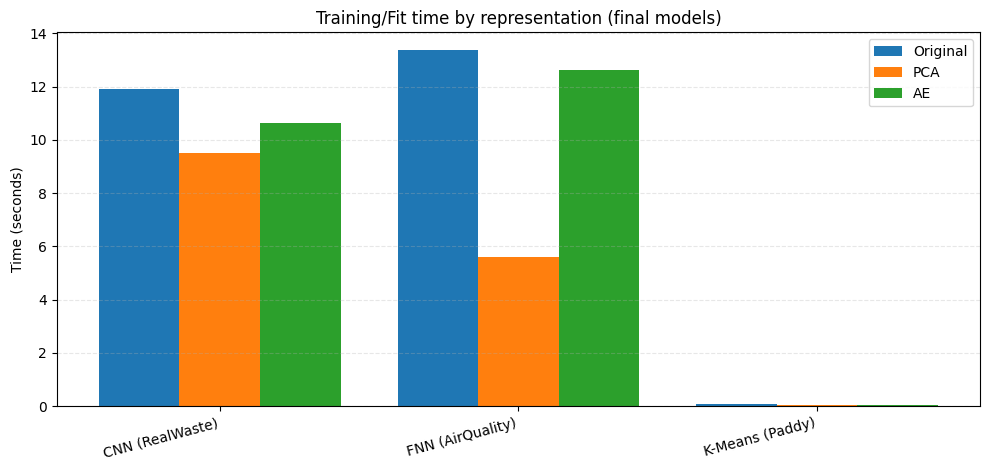

Saved: figures/training_times_barchart.pdf


In [38]:
# --- Export: Training/Fit time bar chart (Original vs PCA vs AE) as PDF for the report ---
os.makedirs("figures", exist_ok=True)

rows = []

# -----------------------------
# 1) KMeans (Paddy) — measure final fit time (if not already stored)
# -----------------------------
def time_kmeans_fit(X, k, seed=42):
    t0 = time.perf_counter()
    km = KMeans(n_clusters=int(k), n_init=10, random_state=seed)
    km.fit(X)
    return float(time.perf_counter() - t0)

kmeans_ready = all(v in globals() for v in ["X_paddy_train", "X_paddy_train_pca", "X_paddy_train_ae",
                                            "k_orig", "k_pca", "k_ae"])
if kmeans_ready:
    t_km_orig = time_kmeans_fit(X_paddy_train,     k_orig, SEED)
    t_km_pca  = time_kmeans_fit(X_paddy_train_pca, k_pca,  SEED)
    t_km_ae   = time_kmeans_fit(X_paddy_train_ae,  k_ae,   SEED)
    rows += [
        {"task": "K-Means (Paddy)", "repr": "original", "time_s": t_km_orig},
        {"task": "K-Means (Paddy)", "repr": "pca",      "time_s": t_km_pca},
        {"task": "K-Means (Paddy)", "repr": "ae",       "time_s": t_km_ae},
    ]

# -----------------------------
# 2) FNN Regression (AirQuality) — prefer results_aq if available
# -----------------------------
if "results_aq" in globals() and "train_time_s" in results_aq.columns:
    for _, r in results_aq.iterrows():
        rows.append({"task": "FNN (AirQuality)", "repr": str(r["repr"]).lower(), "time_s": float(r["train_time_s"])})
elif all(v in globals() for v in ["t_fnn_orig", "t_fnn_pca", "t_fnn_ae"]):
    rows += [
        {"task": "FNN (AirQuality)", "repr": "original", "time_s": float(t_fnn_orig)},
        {"task": "FNN (AirQuality)", "repr": "pca",      "time_s": float(t_fnn_pca)},
        {"task": "FNN (AirQuality)", "repr": "ae",       "time_s": float(t_fnn_ae)},
    ]

# -----------------------------
# 3) CNN Classification (RealWaste) — use the final training times if available
# -----------------------------
if all(v in globals() for v in ["t_cnn_orig", "t_cnn_pca", "t_cnn_ae"]):
    rows += [
        {"task": "CNN (RealWaste)", "repr": "original", "time_s": float(t_cnn_orig)},
        {"task": "CNN (RealWaste)", "repr": "pca",      "time_s": float(t_cnn_pca)},  # PCA reconstruction pipeline
        {"task": "CNN (RealWaste)", "repr": "ae",       "time_s": float(t_cnn_ae)},   # AE reconstruction pipeline
    ]
elif "results_rw" in globals() and "train_time_s" in results_rw.columns:
    # fallback if you stored times in results_rw
    tmp = results_rw.copy()
    tmp["repr"] = tmp["repr"].astype(str).str.lower().replace({"pca_recon": "pca", "ae_recon": "ae"})
    for _, r in tmp.iterrows():
        rows.append({"task": "CNN (RealWaste)", "repr": r["repr"], "time_s": float(r["train_time_s"])})

# -----------------------------
# Build table
# -----------------------------
if len(rows) == 0:
    raise RuntimeError(
        "No timing information found. Make sure you ran the experiments first.\n"
        "Expected: results_aq with train_time_s and/or t_fnn_*, plus t_cnn_* for CNN."
    )

df_time = pd.DataFrame(rows)
df_time["repr"] = df_time["repr"].str.lower().replace({"orig": "original", "pca_recon": "pca", "ae_recon": "ae"})

# Keep only the 3 representations (original/pca/ae) if duplicates exist
df_time = df_time.groupby(["task", "repr"], as_index=False)["time_s"].mean()

display(df_time)

# Pivot for plotting
pivot = df_time.pivot(index="task", columns="repr", values="time_s")

# Ensure consistent column order
for c in ["original", "pca", "ae"]:
    if c not in pivot.columns:
        pivot[c] = np.nan
pivot = pivot[["original", "pca", "ae"]]

# -----------------------------
# Plot grouped bar chart
# -----------------------------
tasks = list(pivot.index)
x = np.arange(len(tasks))
w = 0.27

plt.figure(figsize=(10, 4.8))
plt.bar(x - w, pivot["original"].values, width=w, label="Original")
plt.bar(x,      pivot["pca"].values,     width=w, label="PCA")
plt.bar(x + w,  pivot["ae"].values,      width=w, label="AE")

plt.xticks(x, tasks, rotation=15, ha="right")
plt.ylabel("Time (seconds)")
plt.title("Training/Fit time by representation (final models)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("figures/training_times_barchart.pdf", bbox_inches="tight")
plt.show()

print("Saved: figures/training_times_barchart.pdf")


In [39]:
# =========================
# SUMMARY 2 — RealWaste per-class comparison (TEST)
# =========================

def class_report_df_from_preds(y_true, y_pred, class_names, prefix=""):
    # Build a per-class classification report as a dict (precision/recall/f1/support)
    rep = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    # Convert to DataFrame and keep only the rows corresponding to classes
    df = pd.DataFrame(rep).T
    df = df.loc[class_names, ["precision", "recall", "f1-score", "support"]]
    # Add a prefix to column names to distinguish different models (orig/pca/ae)
    return df.add_prefix(prefix)

# Pick the trained/final models to compare
m_rw_orig = m_orig
m_rw_pca  = m_pca
m_rw_ae   = m_ae

# Get test-set predictions using the existing eval_cnn utility (avoids duplicating get_preds)
# return_preds=True is expected to return (acc, f1_macro, cm, y_true, y_pred) or similar
_, _, _, y_true_o, y_pred_o = eval_cnn(m_rw_orig, test_loader_orig64, return_preds=True)
_, _, _, y_true_p, y_pred_p = eval_cnn(m_rw_pca,  test_loader_pca,    return_preds=True)
_, _, _, y_true_a, y_pred_a = eval_cnn(m_rw_ae,   test_loader_ae,     return_preds=True)

# Build per-class metric tables for each representation
rep_o = class_report_df_from_preds(y_true_o, y_pred_o, class_names, prefix="orig_")
rep_p = class_report_df_from_preds(y_true_p, y_pred_p, class_names, prefix="pca_")
rep_a = class_report_df_from_preds(y_true_a, y_pred_a, class_names, prefix="ae_")

# Merge the three reports side-by-side
rw_per_class = pd.concat([rep_o, rep_p, rep_a], axis=1)

# Compute per-class F1 differences vs the original baseline
rw_per_class["ΔF1_pca_vs_orig"] = rw_per_class["pca_f1-score"] - rw_per_class["orig_f1-score"]
rw_per_class["ΔF1_ae_vs_orig"]  = rw_per_class["ae_f1-score"]  - rw_per_class["orig_f1-score"]

# Display the comparison sorted by AE improvement (worst -> best)
print("\n=== RealWaste per-class comparison (TEST) ===")
display(rw_per_class.sort_values("ΔF1_ae_vs_orig"))



=== RealWaste per-class comparison (TEST) ===


,orig_precision,orig_recall,orig_f1-score,orig_support,pca_precision,pca_recall,pca_f1-score,pca_support,ae_precision,ae_recall,ae_f1-score,ae_support,ΔF1_pca_vs_orig,ΔF1_ae_vs_orig
Food Organics,0.736842,0.677419,0.705882,62.0,0.637681,0.709677,0.671756,62.0,0.442623,0.435484,0.439024,62.0,-0.034127,-0.266858
Cardboard,0.753623,0.753623,0.753623,69.0,0.661290,0.594203,0.625954,69.0,0.470588,0.579710,0.519481,69.0,-0.127669,-0.234143
Vegetation,0.808824,0.846154,0.827068,65.0,0.732394,0.800000,0.764706,65.0,0.627119,0.569231,0.596774,65.0,-0.062362,-0.230293
Textile Trash,0.424658,0.645833,0.512397,48.0,0.577778,0.541667,0.559140,48.0,0.480000,0.250000,0.328767,48.0,0.046743,-0.183630
Metal,0.609589,0.754237,0.674242,118.0,0.620968,0.652542,0.636364,118.0,0.544000,0.576271,0.559671,118.0,-0.037879,-0.114572
Glass,0.818182,0.714286,0.762712,63.0,0.826087,0.603175,0.697248,63.0,0.650794,0.650794,0.650794,63.0,-0.065464,-0.111918
Paper,0.728571,0.680000,0.703448,75.0,0.721519,0.760000,0.740260,75.0,0.650794,0.546667,0.594203,75.0,0.036811,-0.109245
Miscellaneous Trash,0.574074,0.413333,0.480620,75.0,0.467742,0.386667,0.423358,75.0,0.391304,0.360000,0.375000,75.0,-0.057262,-0.105620
Plastic,0.735537,0.644928,0.687259,138.0,0.632258,0.710145,0.668942,138.0,0.564417,0.666667,0.611296,138.0,-0.018317,-0.075963
